# LA PRESENCIA LATINOAMERICANA EN EL CINE ESPAÑOL

Réplica de `6_analisis_exploratorio.ipynb` (proyecto anterior, 177 películas,
pandas sobre CSV) usando el esquema nuevo: **consultas SQL** contra MySQL
(16 tablas + `vista_latam`), 144 películas.

**Cambios de metodología frente al notebook anterior** (documentados aquí
una vez, no se repiten en cada sección):
- **Idiomas**: sección eliminada -- el match por título con TMDB no era fiable.
- **Rating TMDB**: no disponible en este pipeline (nunca se scrapeó a nivel
  película, solo demografía de personas). Sustituido por dos proxies
  propios: subvención media por género (reconocimiento institucional) y
  permanencia media en cartelera (interés sostenido).
- **Género**: antes, multietiqueta -- una película contaba en *todos* sus
  géneros. Ahora se usa `peliculas_generos_padre` (un género por película,
  el más específico, según la regla acordada) -- los conteos no son
  comparables 1:1 con el proyecto anterior.
- **Participación por país**: `porcentaje` en `participacion_pais` viene
  siempre completo (parseado directo de ICAA), no hace falta la imputación
  por reparto equitativo que sí necesitaba el proyecto anterior (basado en
  TMDB) -- no existen columnas `porcentaje_ajustado`/`porcentaje_estimado`.

## 1. Configuración y conexión

In [71]:
import os
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from sqlalchemy import create_engine
from dotenv import load_dotenv

pd.options.display.float_format = '{:,.2f}'.format

load_dotenv()

BASE = Path("..")
CARPETA_GRAFICOS = BASE / "4 - graficos"
CARPETA_GRAFICOS.mkdir(parents=True, exist_ok=True)

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


def consultar(sql):
    """Ejecuta una consulta SQL y devuelve el resultado como DataFrame."""
    return pd.read_sql(sql, engine)


def guardar_grafico(nombre, dpi=150):
    nombre_limpio = re.sub(r"[^\w\-]", "_", nombre.lower()).strip("_")
    ruta = CARPETA_GRAFICOS / f"{nombre_limpio}.png"
    plt.savefig(ruta, dpi=dpi, bbox_inches="tight")
    print(f"Guardado: {ruta}")


sns.set_theme(style="ticks")
print("✓ Configuración lista")


✓ Configuración lista


## 2. Paletas de color

In [118]:
COLORES_SEXO = {
    "hombre": "#1F77B4",
    "mujer": "#AEC7E8",
}

COLORES_LATAM = {
    "Latinoamérica": "#FF7F0E",
    "Resto": "#FFBB78",
}

# Por código ISO -- nacionalidad de persona (direccion/guion.pais).
# Incluye TODAS las nacionalidades que aparecen entre el equipo de
# guion/dirección de las películas LATAM (no solo las 17 LATAM),
# más CR/EC porque son países de coproducción sin nadie de esa
# nacionalidad en el corpus -- se cubren aquí también para que la
# paleta no tenga que ampliarse sobre la marcha en ningún gráfico.
COLORES_PAISES = {
    "AR": "#17BECF",
    "BR": "#98DF8A",
    "CL": "#2CA02C",
    "CO": "#FF9896",
    "CR": "#9467BD",
    "CU": "#C5B0D5",
    "DE": "#8C564B",
    "DK": "#C49C94",
    "DO": "#E377C2",
    "EC": "#F7B6D2",
    "ES": "#7F7F7F",
    "FR": "#C7C7C7",
    "GB": "#BCBD22",
    "IT": "#DBDB8D",
    "MX": "#D62728",
    "NI": "#9EDAE5",
    "PA": "#393B79",
    "PE": "#5254A3",
    "PR": "#6B6ECF",
    "SV": "#9C9EDE",
    "US": "#637939",
    "UY": "#8CA252",
    "VE": "#B5CF6B",
}

# Mismos colores que COLORES_PAISES, indexados por nombre en español --
# para país de coproducción (paises.nombre), que viene así desde ICAA.
COLORES_PAISES_NOMBRE = {
    "Argentina": "#17BECF",
    "Brasil": "#98DF8A",
    "Chile": "#2CA02C",
    "Colombia": "#FF9896",
    "Costa Rica": "#9467BD",
    "Cuba": "#C5B0D5",
    "República Dominicana": "#E377C2",
    "Ecuador": "#F7B6D2",
    "México": "#D62728",
    "Nicaragua": "#9EDAE5",
    "Panamá": "#393B79",
    "Perú": "#5254A3",
    "Puerto Rico": "#6B6ECF",
    "Uruguay": "#8CA252",
    "Venezuela": "#B5CF6B",
}

# Género padre -- solo las 16 categorías presentes en el subset LATAM.
COLORES_GENEROS = {
    "Acción": "#CEDB9C",
    "Animación": "#8C6D31",
    "Aventuras": "#BD9E39",
    "Biográfica": "#E7BA52",
    "Comedia": "#E7CB94",
    "Documental": "#843C39",
    "Drama": "#AD494A",
    "Experimental": "#D6616B",
    "Fantasía": "#E7969C",
    "Ficción": "#7B4173",
    "Histórica": "#A55194",
    "Infantil": "#CE6DBD",
    "Musical": "#DE9ED6",
    "Terror": "#3182BD",
    "Thriller": "#6BAED6",
    "Western": "#9ECAE1",
}

# Las 11 distribuidoras que aparecen en algún gráfico de este notebook
# (Top 10 por volumen U Top 5 por recaudación LATAM) -- nombres exactos
# tal como están en la tabla `distribuidoras`.
COLORES_DISTRIBUIDORAS = {
    "39 ESCALONES FILMS, S.L.": "#C6DBEF",
    "A CONTRACORRIENTE FILMS, S.L.": "#E6550D",
    "AVALON DISTRIBUCION AUDIOVISUAL, S.L.": "#FD8D3C",
    "BEGIN AGAIN FILMS, S.L.": "#FDAE6B",
    "BETA FICTION SPAIN, S.L.": "#FDD0A2",
    "BTEAM PICTURES, S.L.": "#31A354",
    "CASTELAO PICTURES, S.L.": "#74C476",
    "SILDAVIA CINEMA, S.L.": "#A1D99B",
    "SONY PICTURES ENTERTAINMENT IBERIA, S.L.U.": "#C7E9C0",
    "UNIVERSAL PICTURES INTERNATIONAL SPAIN, S.L.": "#756BB1",
    "WARNER BROS ENTERTAINMENT ESPAÑA, S.L.": "#9E9AC8",
}

# Empresas productoras coloreadas por nombre en la sección 11: Top 5 por
# recaudación (Sdb, Ecb Servicios de Producción, Paraíso Torres de Satélite,
# Pampa, Prisma) + Top 5 por recurrencia/num_peliculas (Aleph Media, Mother
# Superior añadidas aquí, el resto ya coincidía).
COLORES_EMPRESAS = {
    "Sdb": "#BCBDDC",
    "Ecb Servicios de Producción": "#DADAEB",
    "Paraíso Torres de Satélite": "#636363",
    "Pampa": "#969696",
    "Prisma": "#BDBDBD",
    "Aleph Media": "#D9D9D9",
    "Mother Superior": "#8DD3C7",
    "Producciones Tondero": "#9A8DD3"
}

todos_los_colores = (
    list(COLORES_SEXO.values()) + list(COLORES_LATAM.values()) + list(COLORES_PAISES.values())
    + list(COLORES_GENEROS.values()) + list(COLORES_DISTRIBUIDORAS.values()) + list(COLORES_EMPRESAS.values())
)
assert len(todos_los_colores) == len(set(todos_los_colores)), "hay colores repetidos entre paletas"
print(f"✓ {len(todos_los_colores)} colores cargados, todos distintos entre las 6 paletas "
      f"(y COLORES_PAISES_NOMBRE reutiliza los de COLORES_PAISES a propósito)")

✓ 62 colores cargados, todos distintos entre las 6 paletas (y COLORES_PAISES_NOMBRE reutiliza los de COLORES_PAISES a propósito)


---
## 3. Alcance del corpus frente al total de "cine español"

Guardado: ..\4 - graficos\peso_corpus_latam_vs_cine_espanol.png


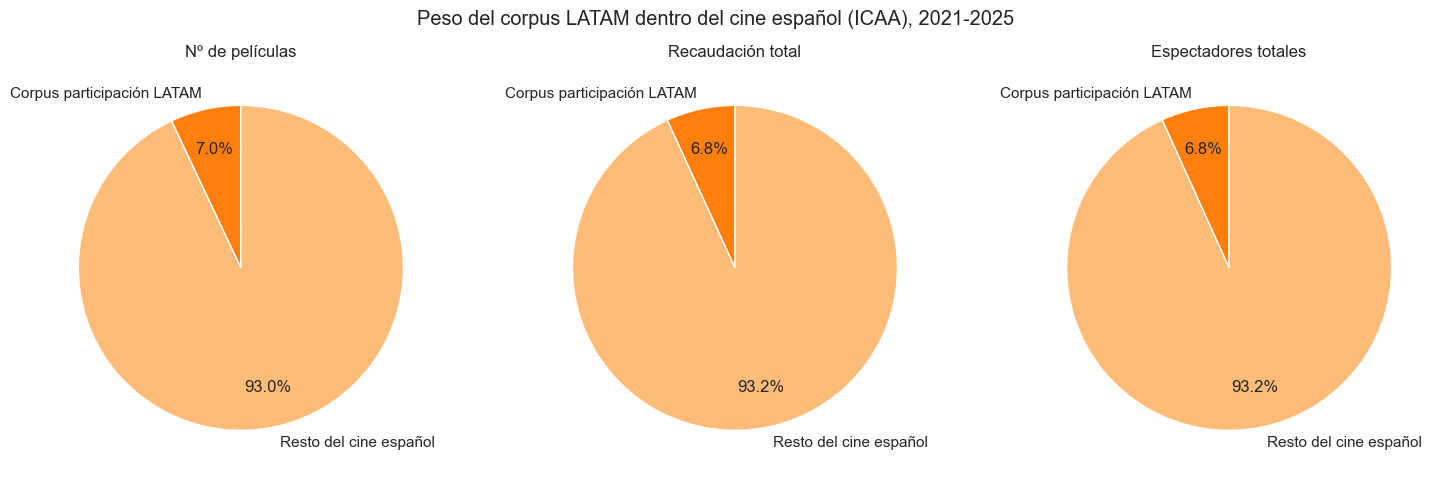

In [73]:
alcance = consultar("""
    SELECT
        (SELECT COUNT(*) FROM peliculas) AS num_peliculas_total,
        (SELECT COUNT(*) FROM vista_latam) AS num_peliculas_latam,
        (SELECT SUM(recaudacion_total) FROM peliculas) AS recaudacion_total,
        (SELECT SUM(recaudacion_total) FROM vista_latam) AS recaudacion_latam,
        (SELECT SUM(espectadores_total) FROM peliculas) AS espectadores_total,
        (SELECT SUM(espectadores_total) FROM vista_latam) AS espectadores_latam
""").iloc[0]

metricas = [
    ("num_peliculas_total", "num_peliculas_latam", "Nº de películas"),
    ("recaudacion_total", "recaudacion_latam", "Recaudación total"),
    ("espectadores_total", "espectadores_latam", "Espectadores totales"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col_total, col_latam, titulo) in zip(axes, metricas):
    subconjunto = alcance[col_latam]
    resto = alcance[col_total] - subconjunto

    ax.pie(
        [subconjunto, resto],
        labels=["Corpus participación LATAM", "Resto del cine español"],
        autopct="%1.1f%%",
        colors=[COLORES_LATAM["Latinoamérica"], COLORES_LATAM["Resto"]],
        startangle=90,
        pctdistance=0.75,   # separa el porcentaje del borde de la cuña
        labeldistance=1.1,  # separa la etiqueta del centro, evita que se pisen
    )
    ax.set_title(titulo)

fig.suptitle("Peso del corpus LATAM dentro del cine español (ICAA), 2021-2025")
plt.tight_layout()
guardar_grafico("peso_corpus_latam_vs_cine_espanol")
plt.show()

**Lectura:** el corpus LATAM representa una fracción minoritaria pero
constante del total de "cine español" registrado por ICAA (2021-2025) --
la gran mayoría de la producción no tiene coproducción latinoamericana
identificada.

---
## 4. Evolución temporal (2021-2025)

Guardado: ..\4 - graficos\peliculas_latam_por_anio.png


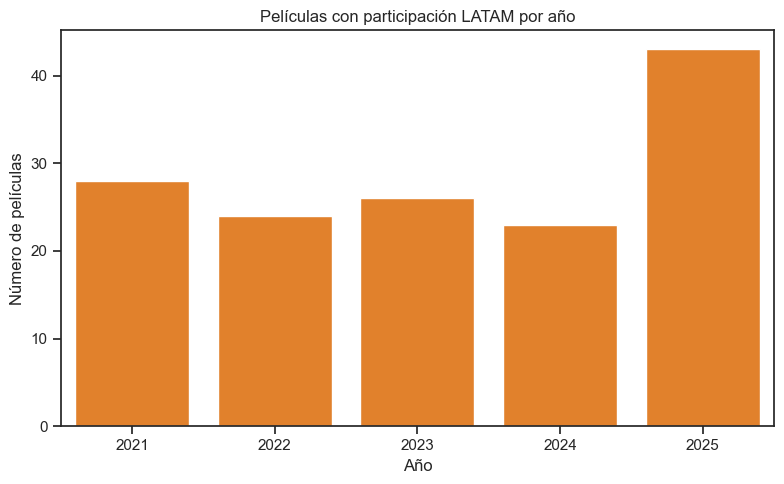

In [74]:
peliculas_por_anio = consultar("""
    SELECT anio, COUNT(*) AS num_peliculas
    FROM vista_latam
    WHERE anio BETWEEN 2021 AND 2025
    GROUP BY anio
    ORDER BY anio
""")

plt.figure(figsize=(8, 5))
sns.barplot(data=peliculas_por_anio, x='anio', y='num_peliculas', color=COLORES_LATAM['Latinoamérica'])
plt.xlabel('Año')
plt.ylabel('Número de películas')
plt.title('Películas con participación LATAM por año')
plt.tight_layout()
guardar_grafico('peliculas_latam_por_anio')
plt.show()


**Lectura:** el volumen de películas con participación LATAM por año de
estreno, 2021-2025.

Guardado: ..\4 - graficos\peliculas_y_recaudacion_por_anio.png


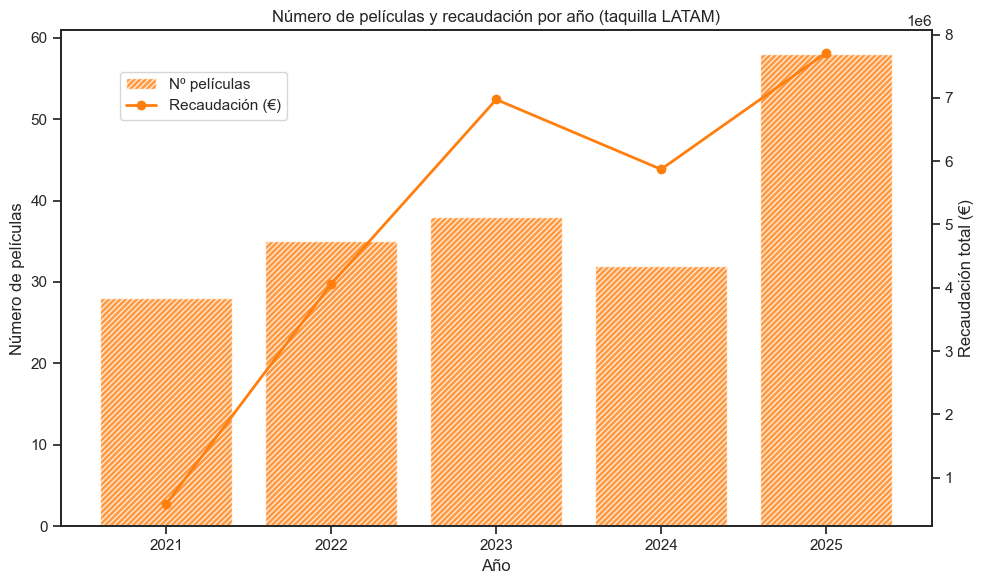

In [75]:
recaudacion_por_anio = consultar("""
    SELECT t.anio, SUM(t.recaudacion) AS recaudacion_total, COUNT(DISTINCT t.pelicula_id) AS num_peliculas
    FROM taquilla_cine_esp t
    JOIN vista_latam v ON v.pelicula_id = t.pelicula_id
    WHERE t.anio BETWEEN 2021 AND 2025
    GROUP BY t.anio
    ORDER BY t.anio
""")

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(recaudacion_por_anio['anio'], recaudacion_por_anio['num_peliculas'],
        color=COLORES_LATAM['Latinoamérica'], alpha=0.8, hatch='//////', label='Nº películas')
ax2.plot(recaudacion_por_anio['anio'], recaudacion_por_anio['recaudacion_total'],
         color=COLORES_LATAM['Latinoamérica'], marker='o', linewidth=2, label='Recaudación (€)')

ax1.set_xlabel('Año')
ax1.set_ylabel('Número de películas')
ax2.set_ylabel('Recaudación total (€)')
ax1.set_xticks(recaudacion_por_anio['anio'])
plt.title('Número de películas y recaudación por año (taquilla LATAM)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
guardar_grafico('peliculas_y_recaudacion_por_anio')
plt.show()


**Lectura:** número de películas y recaudación no necesariamente se mueven
en paralelo -- un año puede tener más títulos sin que eso implique más
recaudación total, si los títulos de otro año concentran más éxitos de
taquilla.

---
## 5. Películas destacadas

### Top 5 películas con más años en cartelera

In [76]:
top_permanencia = consultar("""
    SELECT p.pelicula_id, p.titulo, COUNT(DISTINCT t.anio) AS num_anios,
           GROUP_CONCAT(DISTINCT t.anio ORDER BY t.anio) AS anios_en_cartelera
    FROM vista_latam p
    JOIN taquilla_cine_esp t ON t.pelicula_id = p.pelicula_id
    GROUP BY p.pelicula_id, p.titulo
    ORDER BY num_anios DESC
    LIMIT 5
""")
top_permanencia


,pelicula_id,titulo,num_anios,anios_en_cartelera
0,16,"Gallina Turuleca, La",4,"2021,2022,2023,2024"
1,417,Salvar el arbol (Zutik!),3,"2021,2022,2023"
2,203,Cerrar los ojos,3,"2023,2024,2025"
3,449,"Amor de Andrea, El",3,"2023,2024,2025"
4,685,Sin señas particulares,3,"2021,2022,2025"


### Top 5 películas por espectadores

In [77]:
top_espectadores = consultar("""
    SELECT pelicula_id, titulo, espectadores_total, recaudacion_total
    FROM vista_latam
    ORDER BY espectadores_total DESC
    LIMIT 5
""")
top_espectadores


,pelicula_id,titulo,espectadores_total,recaudacion_total
0,1207,"Navidad en sus manos, La",632111,"4,028,239.00"
1,447,"Familia Beneton, La",622534,"4,067,728.00"
2,236,Un funeral de locos,437336,"3,024,460.00"
3,523,Voy a pasarmelo bien,360315,"2,097,084.00"
4,694,Tierra de nadie,236597,"1,581,015.00"


### Top 5 películas por recaudación

In [78]:
top_recaudacion = consultar("""
    SELECT pelicula_id, titulo, recaudacion_total, espectadores_total
    FROM vista_latam
    ORDER BY recaudacion_total DESC
    LIMIT 5
""")
top_recaudacion


,pelicula_id,titulo,recaudacion_total,espectadores_total
0,447,"Familia Beneton, La","4,067,728.00",622534
1,1207,"Navidad en sus manos, La","4,028,239.00",632111
2,236,Un funeral de locos,"3,024,460.00",437336
3,523,Voy a pasarmelo bien,"2,097,084.00",360315
4,694,Tierra de nadie,"1,581,015.00",236597


**Lectura:** las películas que más recaudan y las que más espectadores
convocan tienden a coincidir, como es de esperar -- el precio medio de
entrada no varía tanto como para invertir el orden.

### Relación entre recaudación y espectadores

Primero sin escala logarítmica, para ver el efecto real de los valores
extremos; después con ella, para comparar el patrón en el grueso de los
datos.

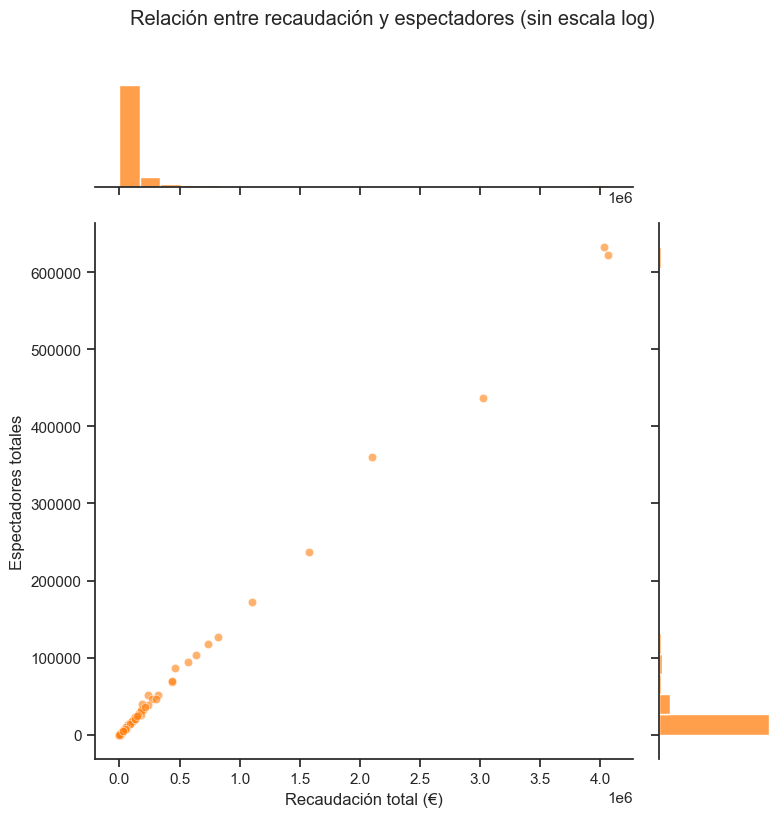

In [79]:
recaudacion_espectadores = consultar("""
    SELECT recaudacion_total, espectadores_total
    FROM vista_latam
    WHERE recaudacion_total IS NOT NULL AND espectadores_total IS NOT NULL
""")

g = sns.jointplot(
    data=recaudacion_espectadores, x='recaudacion_total', y='espectadores_total',
    kind='scatter', height=8, ratio=4, alpha=0.6, color=COLORES_LATAM['Latinoamérica'],
)
g.ax_joint.set_xlabel('Recaudación total (€)')
g.ax_joint.set_ylabel('Espectadores totales')
plt.suptitle('Relación entre recaudación y espectadores (sin escala log)', y=1.02)
plt.tight_layout()
g.savefig(CARPETA_GRAFICOS / 'recaudacion_vs_espectadores_sin_log.png', dpi=150, bbox_inches='tight')
plt.show()


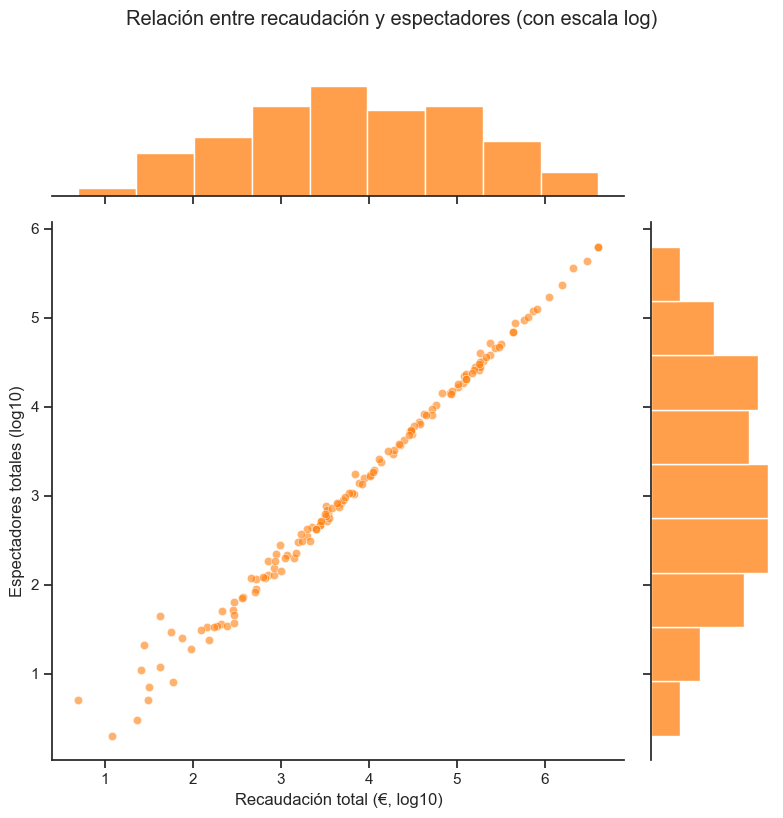

In [80]:
recaudacion_espectadores_log = recaudacion_espectadores.copy()
recaudacion_espectadores_log['log_recaudacion'] = np.log10(recaudacion_espectadores_log['recaudacion_total'])
recaudacion_espectadores_log['log_espectadores'] = np.log10(recaudacion_espectadores_log['espectadores_total'])

g = sns.jointplot(
    data=recaudacion_espectadores_log, x='log_recaudacion', y='log_espectadores',
    kind='scatter', height=8, ratio=4, alpha=0.6, color=COLORES_LATAM['Latinoamérica'],
)
g.ax_joint.set_xlabel('Recaudación total (€, log10)')
g.ax_joint.set_ylabel('Espectadores totales (log10)')
plt.suptitle('Relación entre recaudación y espectadores (con escala log)', y=1.02)
plt.tight_layout()
g.savefig(CARPETA_GRAFICOS / 'recaudacion_vs_espectadores_con_log.png', dpi=150, bbox_inches='tight')
plt.show()


**Lectura:** sin escala log, la nube se concentra casi toda cerca del
origen y unos pocos éxitos dominan visualmente el gráfico. Con escala log,
se aprecia que la relación es prácticamente lineal en todo el rango -- a
más espectadores, más recaudación, de forma consistente incluso entre las
películas modestas.

---
## 6. Distribuidoras


### Ranking de distribuidoras dentro del subset LATAM

In [81]:
ranking_distribuidoras = consultar("""
    SELECT
        d.nombre AS distribuidora,
        COUNT(DISTINCT v.pelicula_id) AS peliculas_latam,
        SUM(v.recaudacion_total) AS recaudacion_total,
        SUM(v.espectadores_total) AS espectadores_total
    FROM vista_latam v
    JOIN peliculas_distribuidoras pd ON pd.pelicula_id = v.pelicula_id
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    WHERE d.nombre != 'Sin distribuidora'
    GROUP BY d.nombre
    ORDER BY recaudacion_total DESC
""")
ranking_distribuidoras.head(10)


,distribuidora,peliculas_latam,recaudacion_total,espectadores_total
0,"SONY PICTURES ENTERTAINMENT IBERIA, S.L.U.",4,"6,828,923.00","1,057,366.00"
1,"A CONTRACORRIENTE FILMS, S.L.",11,"4,974,571.00","794,421.00"
2,"BETA FICTION SPAIN, S.L.",2,"4,889,837.00","749,509.00"
3,"CASTELAO PICTURES, S.L.",20,"1,668,477.00","288,233.00"
4,"WARNER BROS ENTERTAINMENT ESPAÑA, S.L.",3,"1,103,461.00","172,639.00"
5,"UNIVERSAL PICTURES INTERNATIONAL SPAIN, S.L.",4,"889,210.00","151,642.00"
6,"THE WALT DISNEY COMPANY IBERIA, S.L.",3,"836,079.00","134,392.00"
7,"WANDA VISION, S.A.",2,"573,968.00","94,162.00"
8,"AVALON DISTRIBUCION AUDIOVISUAL, S.L.",3,"505,645.00","94,339.00"
9,"VERTICE CINE, S.L.",2,"469,267.00","73,963.00"


In [82]:
top5_distribuidoras = ranking_distribuidoras.head(5)['distribuidora'].tolist()
print("Top 5 distribuidoras (sin 'Sin distribuidora'):", top5_distribuidoras)


Top 5 distribuidoras (sin 'Sin distribuidora'): ['SONY PICTURES ENTERTAINMENT IBERIA, S.L.U.', 'A CONTRACORRIENTE FILMS, S.L.', 'BETA FICTION SPAIN, S.L.', 'CASTELAO PICTURES, S.L.', 'WARNER BROS ENTERTAINMENT ESPAÑA, S.L.']


**Castelao Pictures** pertenece al mismo grupo empresarial que Filmax Pictures/Filmax

### Peso del cine LATAM dentro de cada distribuidora

Guardado: ..\4 - graficos\pct_latam_por_distribuidora_top10.png


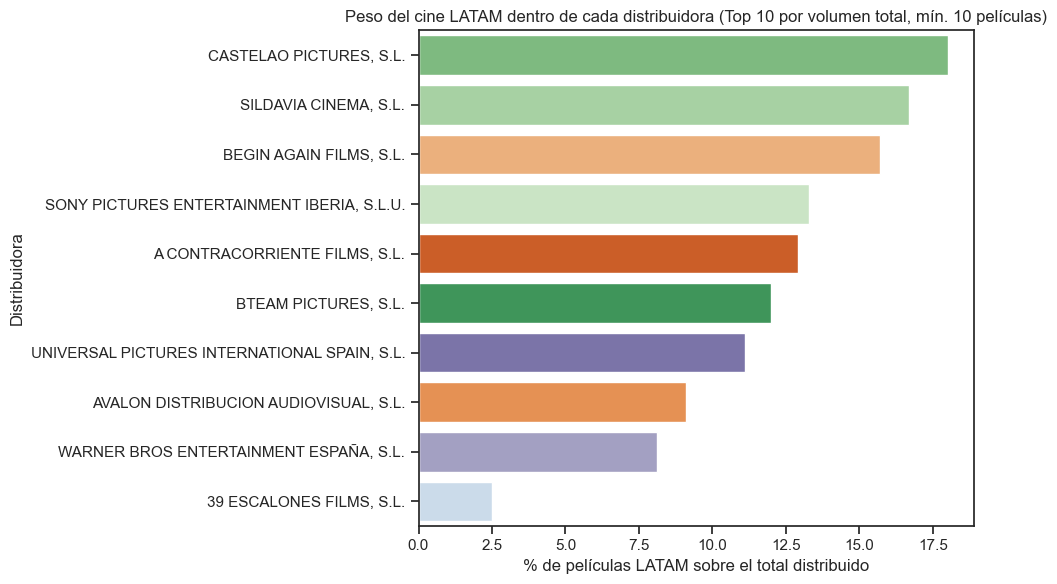

In [83]:
pct_latam_por_distribuidora = consultar("""
    SELECT
        d.nombre AS distribuidora,
        COUNT(DISTINCT pd.pelicula_id) AS total_peliculas,
        COUNT(DISTINCT CASE WHEN pd.pelicula_id IN (
            SELECT pp.pelicula_id FROM participacion_pais pp
            JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
        ) THEN pd.pelicula_id END) AS num_latam
    FROM peliculas_distribuidoras pd
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    WHERE d.nombre != 'Sin distribuidora'
    GROUP BY d.nombre
    HAVING COUNT(DISTINCT pd.pelicula_id) >= 10
""")
pct_latam_por_distribuidora['pct_latam'] = (
    pct_latam_por_distribuidora['num_latam'] / pct_latam_por_distribuidora['total_peliculas'] * 100
).round(1)

top10_volumen = pct_latam_por_distribuidora.nlargest(10, 'total_peliculas').sort_values('pct_latam', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_volumen, x='pct_latam', y='distribuidora', hue='distribuidora',
    palette=COLORES_DISTRIBUIDORAS, legend=False,
)
plt.xlabel('% de películas LATAM sobre el total distribuido')
plt.ylabel('Distribuidora')
plt.title('Peso del cine LATAM dentro de cada distribuidora (Top 10 por volumen total, mín. 10 películas)')
plt.tight_layout()
guardar_grafico('pct_latam_por_distribuidora_top10')
plt.show()


**Lectura:** entre las distribuidoras con más volumen total, algunas
concentran una proporción notablemente mayor de cine LATAM que otras --
esto separa "distribuye mucho cine LATAM en términos absolutos" de
"el cine LATAM pesa proporcionalmente en su catálogo".

### Evolución de la recaudación por distribuidora y año (Top 5)

Guardado: ..\4 - graficos\recaudacion_distribuidora_anio_top5.png


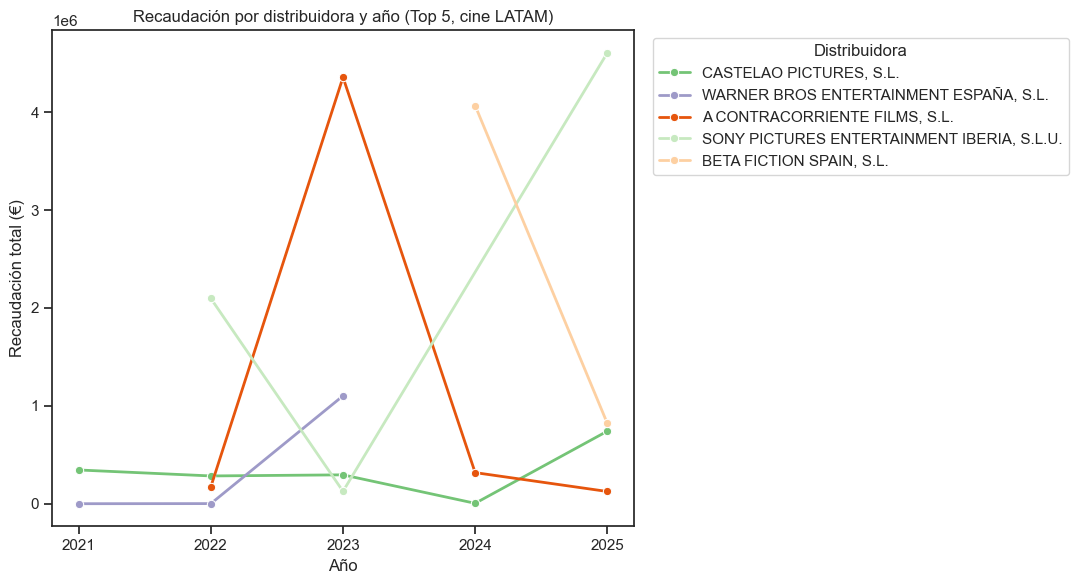

In [84]:
placeholders = ", ".join([f"'{d}'" for d in top5_distribuidoras])
recaudacion_distribuidora_anio = consultar(f"""
    SELECT t.anio, d.nombre AS distribuidora, SUM(t.recaudacion) AS recaudacion_total
    FROM taquilla_cine_esp t
    JOIN peliculas_distribuidoras pd ON pd.pelicula_id = t.pelicula_id
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    JOIN vista_latam v ON v.pelicula_id = t.pelicula_id
    WHERE d.nombre IN ({placeholders})
    GROUP BY t.anio, d.nombre
    ORDER BY t.anio
""")

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=recaudacion_distribuidora_anio, x='anio', y='recaudacion_total',
    hue='distribuidora', palette=COLORES_DISTRIBUIDORAS, marker='o', linewidth=2,
)
plt.xticks(sorted(recaudacion_distribuidora_anio['anio'].unique()))
plt.xlabel('Año')
plt.ylabel('Recaudación total (€)')
plt.title('Recaudación por distribuidora y año (Top 5, cine LATAM)')
plt.legend(title='Distribuidora', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('recaudacion_distribuidora_anio_top5')
plt.show()


**Lectura:** la recaudación de las principales distribuidoras no es
estable año a año -- picos puntuales suelen deberse a un único título de
gran éxito más que a una tendencia sostenida.

### País principal por distribuidora, en recaudación (Top 5)

In [85]:
placeholders = ", ".join([f"'{d}'" for d in top5_distribuidoras])
pais_por_distribuidora_recaudacion = consultar(f"""
    SELECT d.nombre AS distribuidora, pa.nombre AS pais,
           SUM(v.recaudacion_total * pp.porcentaje / 100) AS recaudacion_prorrateada
    FROM vista_latam v
    JOIN peliculas_distribuidoras pd ON pd.pelicula_id = v.pelicula_id
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    WHERE d.nombre IN ({placeholders})
    GROUP BY d.nombre, pa.nombre
""")

pais_principal_por_recaudacion = (
    pais_por_distribuidora_recaudacion
    .sort_values('recaudacion_prorrateada', ascending=False)
    .drop_duplicates('distribuidora')
    .rename(columns={'pais': 'pais_principal_por_recaudacion'})
    .sort_values('recaudacion_prorrateada', ascending=False)
)
pais_principal_por_recaudacion


,distribuidora,pais_principal_por_recaudacion,recaudacion_prorrateada
7,"SONY PICTURES ENTERTAINMENT IBERIA, S.L.U.",México,"1,365,784.60"
9,"BETA FICTION SPAIN, S.L.",México,"977,967.40"
10,"A CONTRACORRIENTE FILMS, S.L.",México,"889,580.89"
0,"WARNER BROS ENTERTAINMENT ESPAÑA, S.L.",Argentina,"221,268.81"
5,"CASTELAO PICTURES, S.L.",Colombia,"127,342.40"


**Lectura:** recaudación prorrateada por porcentaje de participación --
si una distribuidora estrena una coproducción España-Argentina-México
50/30/20, cada país recibe la parte proporcional, no el total.

Guardado: ..\4 - graficos\recaudacion_prorrateada_top3pais_por_distribuidora_top5.png


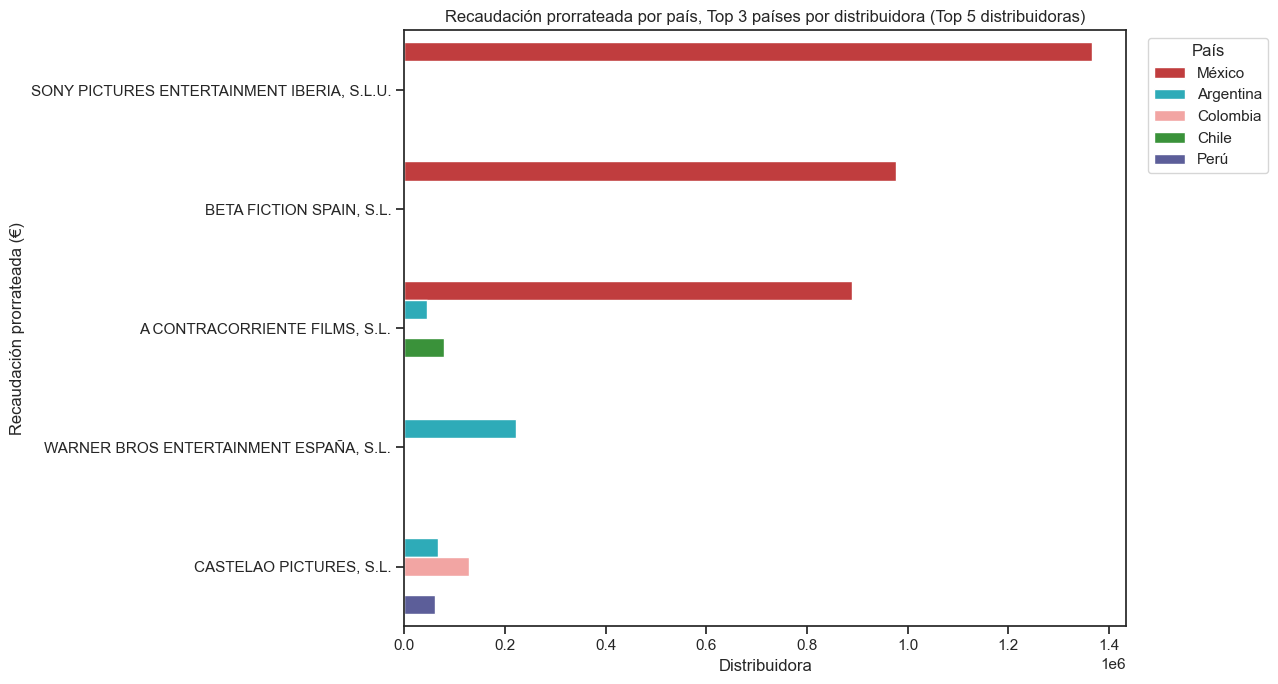

In [86]:
top3_pais_por_distribuidora = (
    pais_por_distribuidora_recaudacion
    .sort_values('recaudacion_prorrateada', ascending=False)
    .groupby('distribuidora')
    .head(3)
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=top3_pais_por_distribuidora, y='distribuidora', x='recaudacion_prorrateada', orient='h',
    hue='pais', palette=COLORES_PAISES_NOMBRE,
)

plt.xlabel('Distribuidora')
plt.ylabel('Recaudación prorrateada (€)')
plt.title('Recaudación prorrateada por país, Top 3 países por distribuidora (Top 5 distribuidoras)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('recaudacion_prorrateada_top3pais_por_distribuidora_top5')
plt.show()

**Lectura:** dentro de cada distribuidora, se ve si su recaudación LATAM
depende de un solo país (una barra dominante, como Beta Fiction o Sony,
que solo trabajaron con uno) o está repartida entre varios (como Castelao,
con 8 países distintos, aunque probablemente con montos muy desiguales
entre ellos).

### Género principal por distribuidora, en recaudación (Top 5)

In [87]:
placeholders = ", ".join([f"'{d}'" for d in top5_distribuidoras])
genero_top_por_distribuidora = consultar(f"""
    SELECT d.nombre AS distribuidora, gp.genero_padre,
           SUM(v.recaudacion_total) AS recaudacion_total
    FROM vista_latam v
    JOIN peliculas_distribuidoras pd ON pd.pelicula_id = v.pelicula_id
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    WHERE d.nombre IN ({placeholders})
    GROUP BY d.nombre, gp.genero_padre
""")
genero_top_por_distribuidora = (
    genero_top_por_distribuidora
    .sort_values('recaudacion_total', ascending=False)
    .drop_duplicates('distribuidora')
    .sort_values('recaudacion_total')
)
genero_top_por_distribuidora


,distribuidora,genero_padre,recaudacion_total
8,"CASTELAO PICTURES, S.L.",Aventuras,"636,712.00"
2,"WARNER BROS ENTERTAINMENT ESPAÑA, S.L.",Comedia,"1,103,419.00"
10,"SONY PICTURES ENTERTAINMENT IBERIA, S.L.U.",Comedia,"3,024,460.00"
12,"BETA FICTION SPAIN, S.L.",Comedia,"4,067,728.00"
11,"A CONTRACORRIENTE FILMS, S.L.",Comedia,"4,403,847.00"


**Lectura:** cada distribuidora del Top 5 tiene un género que concentra la
mayor parte de su recaudación LATAM -- si coincide con el género principal
de varias distribuidoras, sugiere que ese género es el que mejor
funciona comercialmente en general, no una especialidad de una sola casa.

### Concentración por país LATAM principal, en número de títulos (Top 5 distribuidoras)

Guardado: ..\4 - graficos\concentracion_pais_principal_distribuidora_top5.png


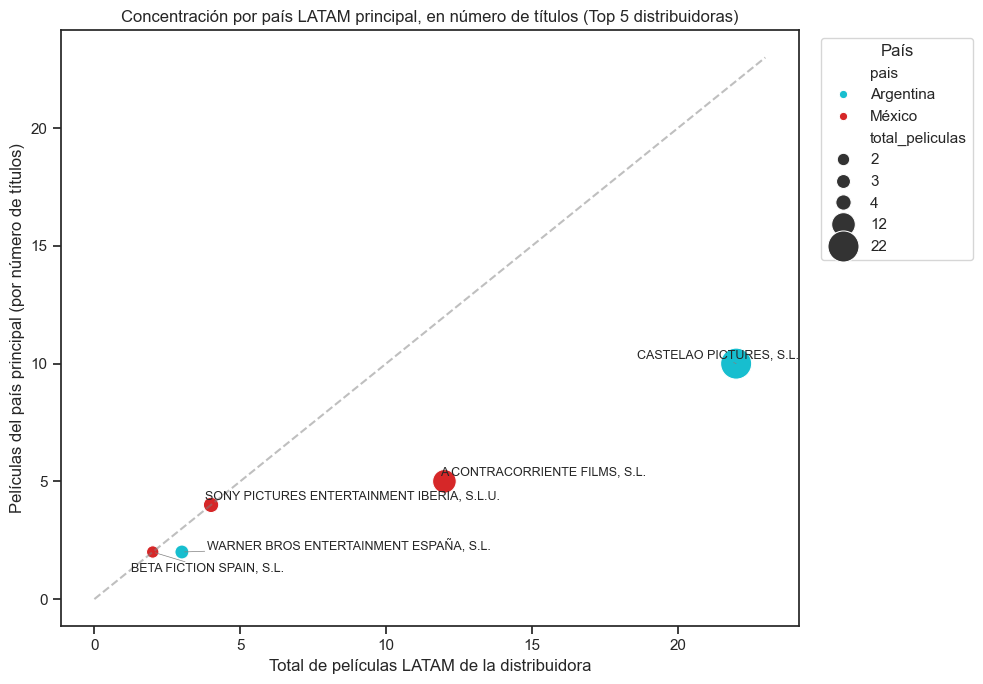

In [88]:
placeholders = ", ".join([f"'{d}'" for d in top5_distribuidoras])
pais_por_distribuidora_num_peliculas = consultar(f"""
    SELECT d.nombre AS distribuidora, pa.nombre AS pais,
           COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_distribuidoras pd ON pd.pelicula_id = v.pelicula_id
    JOIN distribuidoras d ON d.distribuidora_id = pd.distribuidora_id
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    WHERE d.nombre IN ({placeholders})
    GROUP BY d.nombre, pa.nombre
""")

total_por_distribuidora = pais_por_distribuidora_num_peliculas.groupby('distribuidora')['num_peliculas'].sum().rename('total_peliculas')

pais_principal_por_num_peliculas = (
    pais_por_distribuidora_num_peliculas
    .sort_values('num_peliculas', ascending=False)
    .drop_duplicates('distribuidora')
    .merge(total_por_distribuidora, on='distribuidora')
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pais_principal_por_num_peliculas, x='total_peliculas', y='num_peliculas',
    hue='pais', palette=COLORES_PAISES_NOMBRE, size='total_peliculas', sizes=(80, 500),
)
lim = pais_principal_por_num_peliculas['total_peliculas'].max() + 1
plt.plot([0, lim], [0, lim], linestyle='--', color='gray', alpha=0.5)

textos = [
    plt.text(fila['total_peliculas'], fila['num_peliculas'], fila['distribuidora'], fontsize=9)
    for _, fila in pais_principal_por_num_peliculas.iterrows()
]
adjust_text(textos, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.xlabel('Total de películas LATAM de la distribuidora')
plt.ylabel('Películas del país principal (por número de títulos)')
plt.title('Concentración por país LATAM principal, en número de títulos (Top 5 distribuidoras)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('concentracion_pais_principal_distribuidora_top5')
plt.show()


**Lectura:** los puntos cerca de la diagonal indican distribuidoras muy
concentradas en un único país LATAM (en número de títulos, no en
recaudación -- ver la sección anterior para el criterio por dinero); los
que se alejan hacia la derecha reparten su catálogo entre varios países
distintos.

---
## 7. Géneros

`peliculas_generos_padre` da un único género por película (el más
específico).

### Películas por género y año

Guardado: ..\4 - graficos\peliculas_genero_anio_heatmap.png


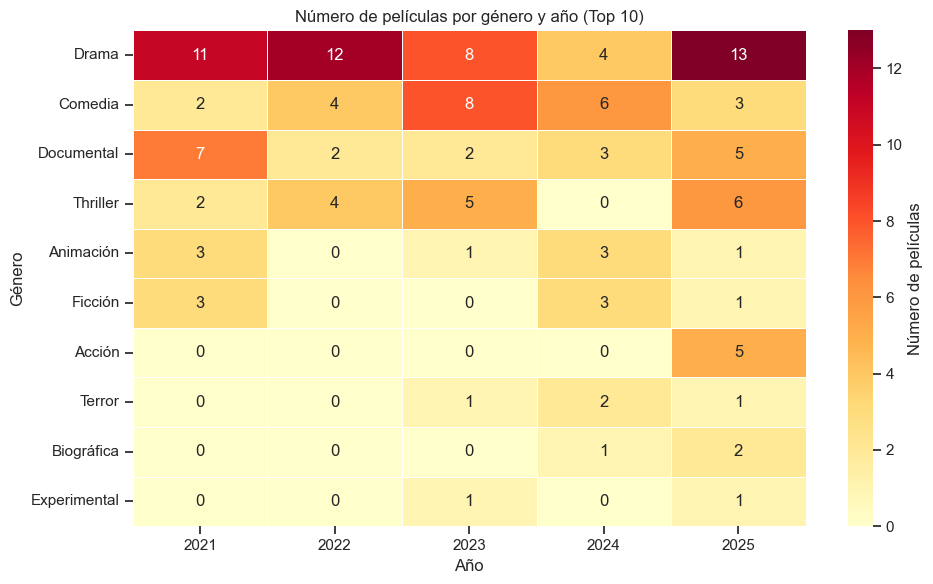

In [89]:
peliculas_genero_anio = consultar("""
    SELECT v.anio, gp.genero_padre, COUNT(*) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    WHERE v.anio BETWEEN 2021 AND 2025
    GROUP BY v.anio, gp.genero_padre
""")

pivot_genero = peliculas_genero_anio.pivot(index='anio', columns='genero_padre', values='num_peliculas').fillna(0)
top10 = pivot_genero.sum().sort_values(ascending=False).head(10).index
pivot_top10 = pivot_genero[top10]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_top10.T, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Número de películas'})
plt.title('Número de películas por género y año (Top 10)')
plt.xlabel('Año')
plt.ylabel('Género')
plt.tight_layout()
guardar_grafico('peliculas_genero_anio_heatmap')
plt.show()


**Lectura:** Drama y Documental dominan casi todos los años -- coherente
con lo que ya vimos en la constelación de hechos, son las dos categorías
que más absorben a otras al agrupar por género padre.

### Recaudación por género

In [90]:
estadisticas_genero = consultar("""
    SELECT gp.genero_padre,
           COUNT(*) AS num_peliculas,
           SUM(v.recaudacion_total) AS recaudacion_total,
           AVG(v.recaudacion_total) AS recaudacion_media,
           STDDEV(v.recaudacion_total) AS std
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    GROUP BY gp.genero_padre
    ORDER BY recaudacion_total DESC
""")
estadisticas_genero['pct_total'] = (estadisticas_genero['recaudacion_total'] / estadisticas_genero['recaudacion_total'].sum() * 100).round(2)
estadisticas_genero['cv'] = (estadisticas_genero['std'] / estadisticas_genero['recaudacion_media']).round(2)
estadisticas_genero.round(2)


,genero_padre,num_peliculas,recaudacion_total,recaudacion_media,std,pct_total,cv
0,Comedia,23,"14,428,678.00","627,333.83","1,231,818.46",57.24,1.96
1,Musical,2,"2,919,193.00","1,459,596.50","637,487.50",11.58,0.44
2,Thriller,17,"2,702,217.00","158,953.94","160,705.10",10.72,1.01
3,Acción,5,"1,848,204.00","369,640.80","609,066.76",7.33,1.65
4,Drama,48,"1,520,924.00","31,685.92","93,183.60",6.03,2.94
5,Aventuras,1,"636,712.00","636,712.00",0.00,2.53,0.00
6,Terror,4,"375,321.00","93,830.25","83,469.60",1.49,0.89
7,Animación,8,"334,654.00","41,831.75","53,474.13",1.33,1.28
8,Documental,19,"256,875.00","13,519.74","36,273.48",1.02,2.68
9,Ficción,7,"109,606.00","15,658.00","14,837.84",0.43,0.95


**Lectura:** un género puede dominar la recaudación total con relativamente
pocas películas si tiene éxitos de taquilla muy grandes -- el coeficiente
de variación (`cv`) señala qué géneros son más heterogéneos (unos pocos
éxitos y el resto modesto) frente a los más homogéneos.

### Distribución de recaudación por género

Primero un `boxplot` (resumen de cuartiles, más legible con pocas
categorías); después un `violinplot` sobre los mismos datos, que además
muestra la forma completa de la distribución (bimodalidades, colas).

Guardado: ..\4 - graficos\distribucion_recaudacion_por_genero_boxplot.png


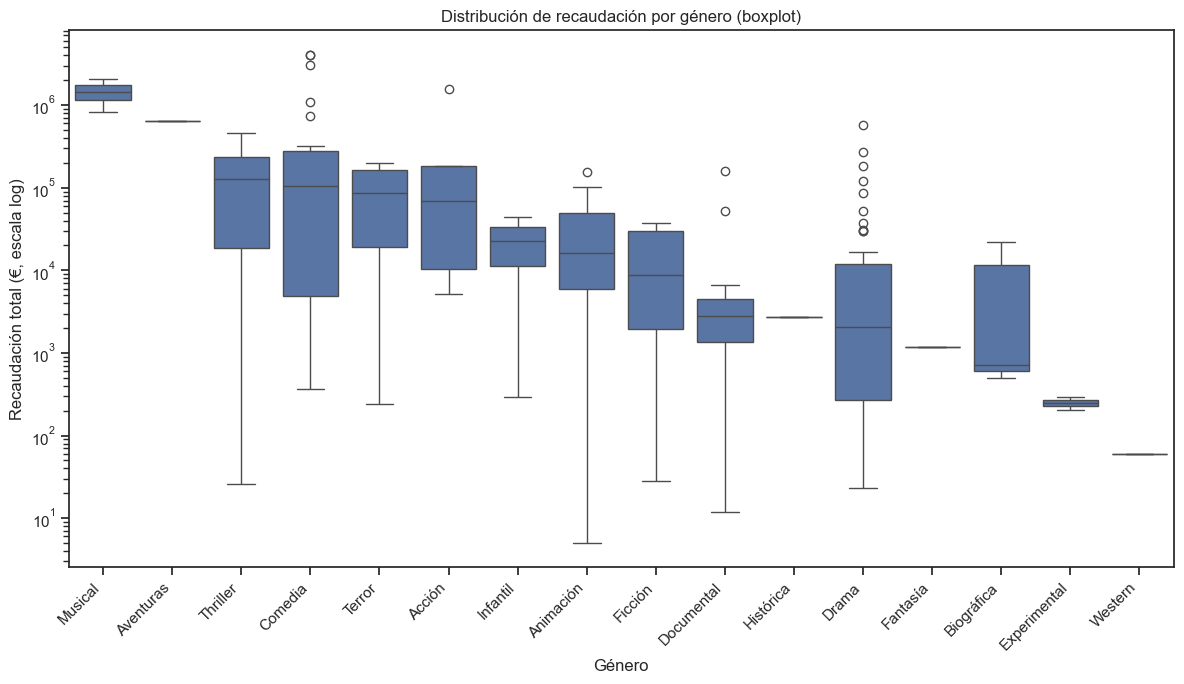

In [91]:
generos_con_taquilla = consultar("""
    SELECT gp.genero_padre, v.recaudacion_total
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    WHERE v.recaudacion_total IS NOT NULL
""")
orden_generos = generos_con_taquilla.groupby('genero_padre')['recaudacion_total'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))
sns.boxplot(data=generos_con_taquilla, x='genero_padre', y='recaudacion_total', order=orden_generos)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Recaudación total (€, escala log)')
plt.xlabel('Género')
plt.title('Distribución de recaudación por género (boxplot)')
plt.tight_layout()
guardar_grafico('distribucion_recaudacion_por_genero_boxplot')
plt.show()


Guardado: ..\4 - graficos\distribucion_recaudacion_por_genero_violin.png


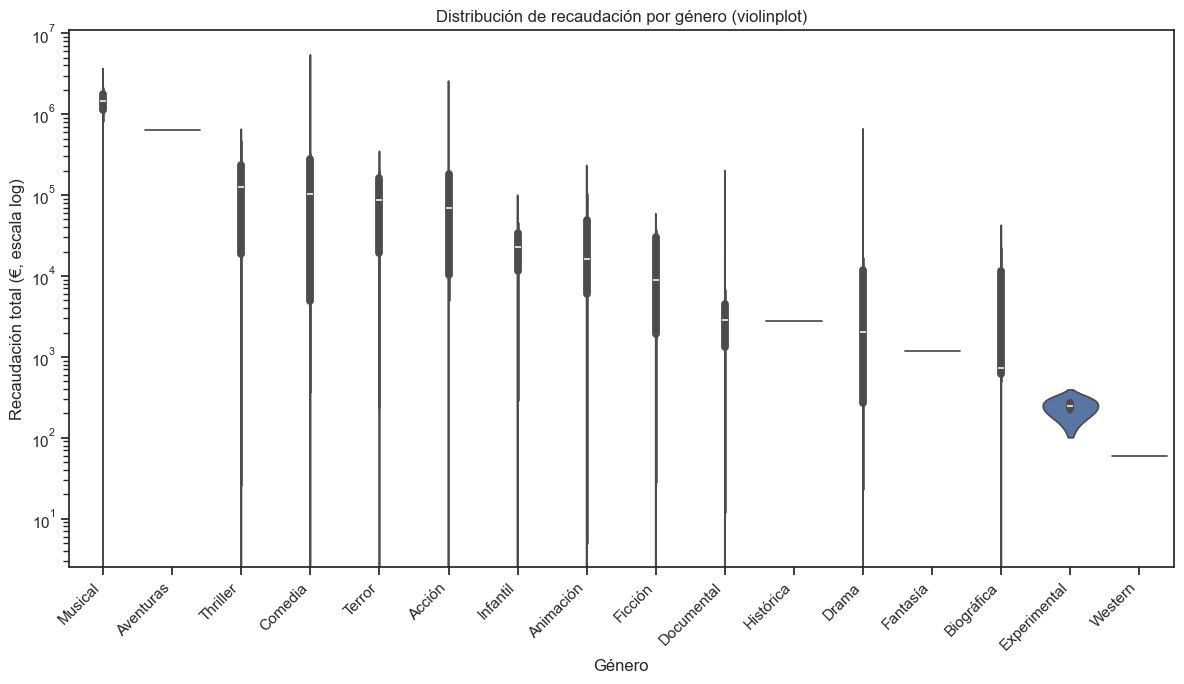

In [92]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=generos_con_taquilla, x='genero_padre', y='recaudacion_total', order=orden_generos)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Recaudación total (€, escala log)')
plt.xlabel('Género')
plt.title('Distribución de recaudación por género (violinplot)')
plt.tight_layout()
guardar_grafico('distribucion_recaudacion_por_genero_violin')
plt.show()


**Lectura:** el `boxplot` ya deja ver medianas y dispersión por género;
el `violinplot` añade la forma -- por ejemplo, un género con distribución
bimodal (grupos de éxito y de fracaso, sin término medio) se ve como una
silueta con dos "bultos", algo que el boxplot no puede mostrar.

### Género, recaudación y dos proxies de "valorado vs. comercial"

Se usan dos medidas propias, ambas
verificadas por ICAA:
- **Subvención media**: las subvenciones se conceden por mérito
  artístico/cultural, no por potencial comercial -- géneros con mucha
  recaudación y poca subvención son "comerciales, no necesitan apoyo";
  géneros con poca recaudación y mucha subvención son "valorados
  institucionalmente, dependen del apoyo para existir".
- **Permanencia media en cartelera** (nº de años distintos en
  `taquilla_cine_esp`): mide interés sostenido en el tiempo, independiente
  del total recaudado -- un género de éxito de estreno inmediato que luego
  desaparece frente a uno de recorrido más largo.

Guardado: ..\4 - graficos\genero_recaudacion_vs_subvencion.png


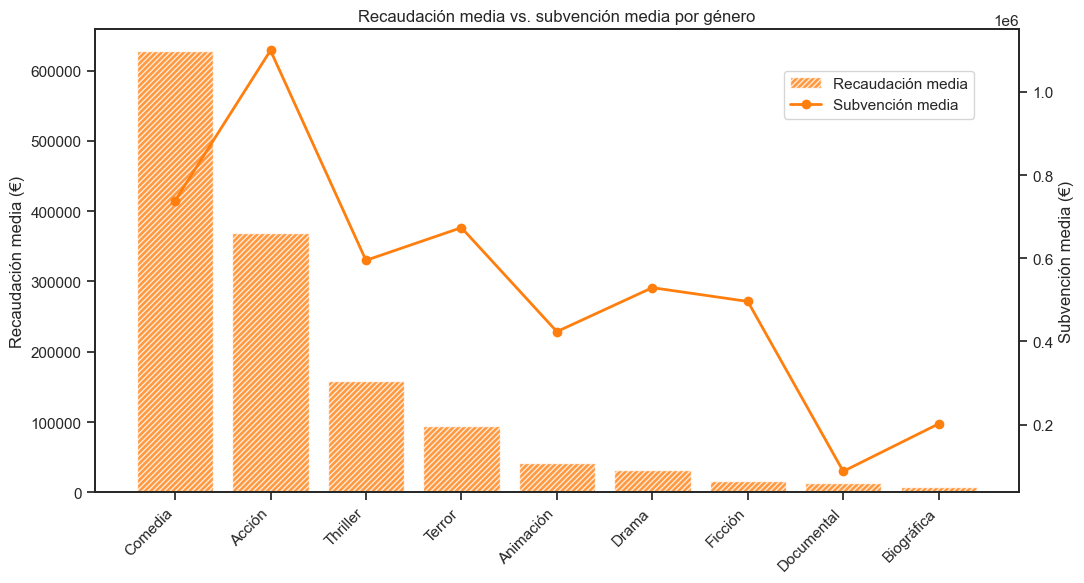

In [93]:
genero_subvencion = consultar("""
    SELECT gp.genero_padre,
           AVG(v.recaudacion_total) AS recaudacion_media,
           AVG(s.total_subvencion) AS subvencion_media
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    LEFT JOIN (
        SELECT pelicula_id, SUM(importe) AS total_subvencion
        FROM subvenciones
        GROUP BY pelicula_id
    ) s ON s.pelicula_id = v.pelicula_id
    GROUP BY gp.genero_padre
    HAVING COUNT(*) >= 3
""")
genero_subvencion['subvencion_media'] = genero_subvencion['subvencion_media'].fillna(0)

fig, ax1 = plt.subplots(figsize=(11, 6))
orden = genero_subvencion.sort_values('recaudacion_media', ascending=False)['genero_padre']
ax2 = ax1.twinx()

x = range(len(orden))
datos_ordenados = genero_subvencion.set_index('genero_padre').loc[orden]

ax1.bar(x, datos_ordenados['recaudacion_media'], color=COLORES_LATAM['Latinoamérica'], alpha=0.8, hatch='//////', label='Recaudación media')
ax2.plot(x, datos_ordenados['subvencion_media'], color=COLORES_LATAM['Latinoamérica'], marker='o', linewidth=2, label='Subvención media')

ax1.set_xticks(x)
ax1.set_xticklabels(orden, rotation=45, ha='right')
ax1.set_ylabel('Recaudación media (€)')
ax2.set_ylabel('Subvención media (€)')
plt.title('Recaudación media vs. subvención media por género')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
guardar_grafico('genero_recaudacion_vs_subvencion')
plt.show()


Guardado: ..\4 - graficos\genero_recaudacion_vs_subvencion.png


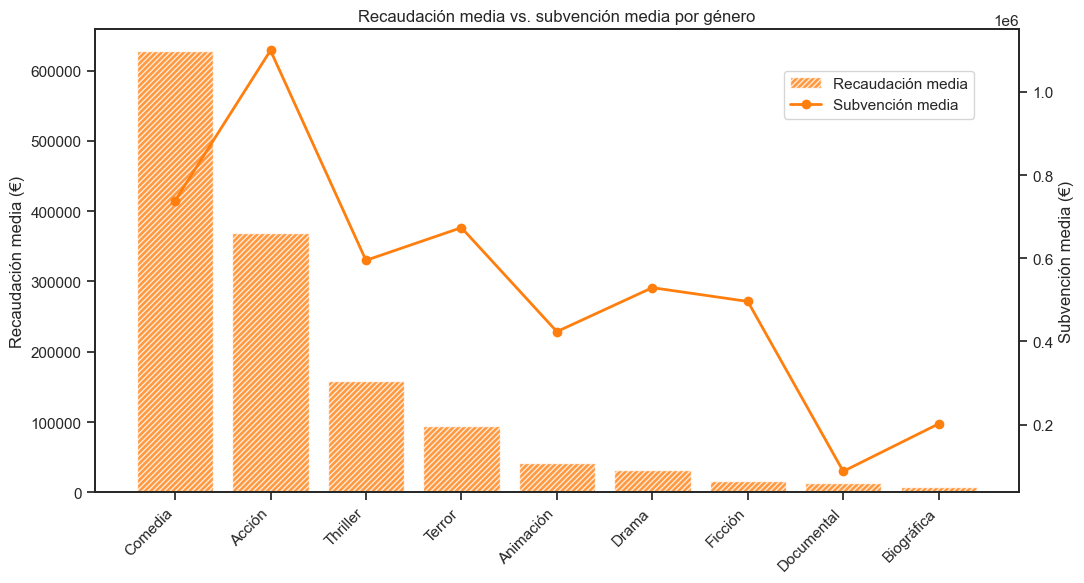

In [94]:
genero_subvencion = consultar("""
    SELECT 
        gp.genero_padre,
        
        COUNT(DISTINCT v.pelicula_id) AS n_peliculas,
        
        COUNT(DISTINCT CASE 
            WHEN s.total_subvencion IS NOT NULL 
            THEN v.pelicula_id 
        END) AS n_subvencionadas,
        
        AVG(v.recaudacion_total) AS recaudacion_media,
        
        AVG(s.total_subvencion) AS subvencion_media
        
    FROM vista_latam v
    
    JOIN peliculas_generos_padre gp 
        ON gp.pelicula_id = v.pelicula_id
    
    LEFT JOIN (
        SELECT 
            pelicula_id, 
            SUM(importe) AS total_subvencion
        FROM subvenciones
        GROUP BY pelicula_id
    ) s 
        ON s.pelicula_id = v.pelicula_id
    
    GROUP BY gp.genero_padre
    
    HAVING COUNT(DISTINCT v.pelicula_id) >= 3
""")

# Si un género no tiene ninguna película subvencionada,
# AVG(s.total_subvencion) será NaN → lo dejamos en 0 para el gráfico
genero_subvencion['subvencion_media'] = (
    genero_subvencion['subvencion_media'].fillna(0)
)

# Ordenar por recaudación media
orden = (
    genero_subvencion
    .sort_values('recaudacion_media', ascending=False)
    ['genero_padre']
)

datos_ordenados = (
    genero_subvencion
    .set_index('genero_padre')
    .loc[orden]
)

# -----------------------------
# GRÁFICO
# -----------------------------

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

x = range(len(orden))

ax1.bar(
    x,
    datos_ordenados['recaudacion_media'],
    color=COLORES_LATAM['Latinoamérica'],
    alpha=0.8,
    hatch='//////',
    label='Recaudación media'
)

ax2.plot(
    x,
    datos_ordenados['subvencion_media'],
    color=COLORES_LATAM['Latinoamérica'],
    marker='o',
    linewidth=2,
    label='Subvención media'
)

ax1.set_xticks(x)
ax1.set_xticklabels(orden, rotation=45, ha='right')

ax1.set_ylabel('Recaudación media (€)')
ax2.set_ylabel('Subvención media (€)')

plt.title('Recaudación media vs. subvención media por género')

fig.legend(
    loc='upper right',
    bbox_to_anchor=(0.9, 0.88)
)

plt.tight_layout()

guardar_grafico('genero_recaudacion_vs_subvencion')

plt.show()

In [95]:
genero_subvencion

,genero_padre,n_peliculas,n_subvencionadas,recaudacion_media,subvencion_media
0,Acción,5,2,"369,640.80","1,100,000.00"
1,Animación,8,6,"41,831.75","423,583.33"
2,Biográfica,3,1,"7,842.33","201,819.00"
3,Comedia,23,14,"627,333.83","738,323.73"
4,Documental,19,12,"13,519.74","87,589.66"
5,Drama,48,30,"31,685.92","529,284.88"
6,Ficción,7,3,"15,658.00","496,215.67"
7,Terror,4,3,"93,830.25","673,666.67"
8,Thriller,17,11,"158,953.94","595,002.64"


Guardado: ..\4 - graficos\genero_recaudacion_vs_subvencion_mediana.png


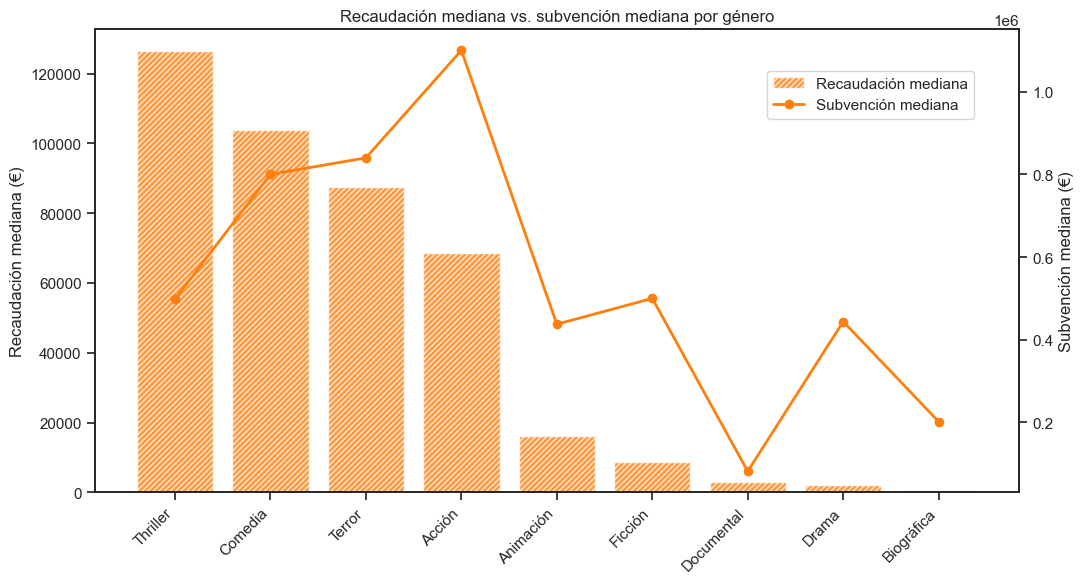

In [96]:
genero_subvencion = consultar("""
    SELECT 
        v.pelicula_id,
        gp.genero_padre,
        v.recaudacion_total,
        s.total_subvencion

    FROM vista_latam v

    JOIN peliculas_generos_padre gp 
        ON gp.pelicula_id = v.pelicula_id

    LEFT JOIN (
        SELECT 
            pelicula_id,
            SUM(importe) AS total_subvencion
        FROM subvenciones
        GROUP BY pelicula_id
    ) s 
        ON s.pelicula_id = v.pelicula_id
""")

# --------------------------------------------------
# AGRUPACIÓN POR GÉNERO
# --------------------------------------------------

genero_subvencion = (
    genero_subvencion
    .groupby('genero_padre')
    .agg(
        n_peliculas=('pelicula_id', 'nunique'),
        
        n_subvencionadas=(
            'total_subvencion',
            lambda x: x.notna().sum()
        ),
        
        recaudacion_mediana=('recaudacion_total', 'median'),
        
        subvencion_mediana=('total_subvencion', 'median')
    )
    .reset_index()
)

# Nos quedamos con géneros que tengan al menos 3 películas
genero_subvencion = genero_subvencion[
    genero_subvencion['n_peliculas'] >= 3
].copy()

# Si un género no tiene ninguna película subvencionada,
# su mediana será NaN → 0 para el gráfico
genero_subvencion['subvencion_mediana'] = (
    genero_subvencion['subvencion_mediana'].fillna(0)
)

# --------------------------------------------------
# ORDENAR POR RECAUDACIÓN
# --------------------------------------------------

orden = (
    genero_subvencion
    .sort_values('recaudacion_mediana', ascending=False)
    ['genero_padre']
)

datos_ordenados = (
    genero_subvencion
    .set_index('genero_padre')
    .loc[orden]
)

# --------------------------------------------------
# GRÁFICO
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

x = range(len(orden))

ax1.bar(
    x,
    datos_ordenados['recaudacion_mediana'],
    color=COLORES_LATAM['Latinoamérica'],
    alpha=0.8,
    hatch='//////',
    label='Recaudación mediana'
)

ax2.plot(
    x,
    datos_ordenados['subvencion_mediana'],
    color=COLORES_LATAM['Latinoamérica'],
    marker='o',
    linewidth=2,
    label='Subvención mediana'
)

ax1.set_xticks(x)
ax1.set_xticklabels(orden, rotation=45, ha='right')

ax1.set_ylabel('Recaudación mediana (€)')
ax2.set_ylabel('Subvención mediana (€)')

plt.title('Recaudación mediana vs. subvención mediana por género')

fig.legend(
    loc='upper right',
    bbox_to_anchor=(0.9, 0.88)
)

plt.tight_layout()

guardar_grafico('genero_recaudacion_vs_subvencion_mediana')

plt.show()

**Lectura:** los géneros donde la barra de recaudación es alta y la línea
de subvención es baja son los más "autosuficientes" comercialmente; donde
pasa lo contrario, son géneros que la política pública sostiene más de lo
que el mercado los premia.

Guardado: ..\4 - graficos\genero_recaudacion_vs_permanencia.png


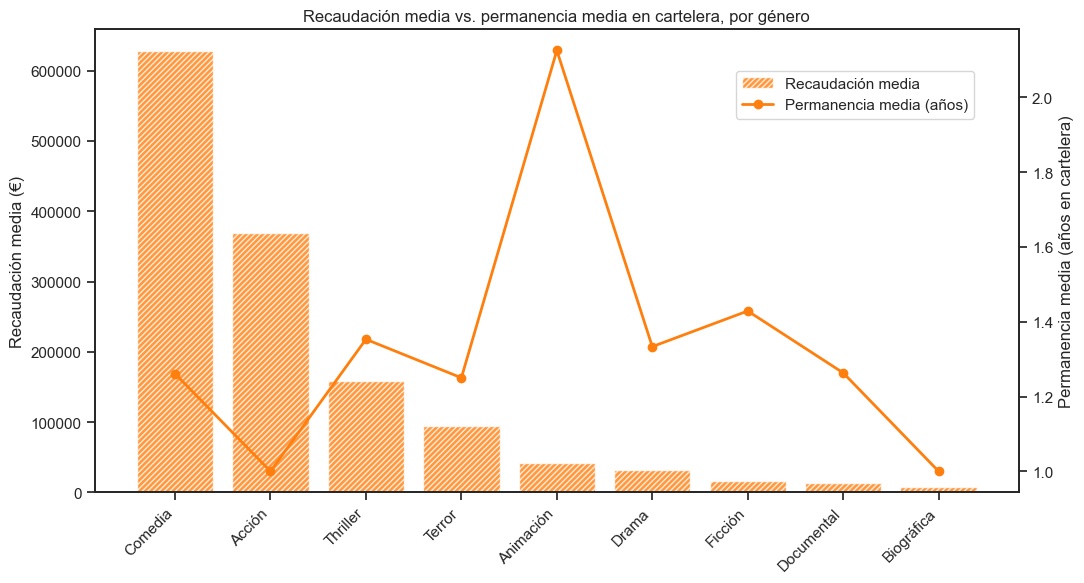

In [97]:
genero_permanencia = consultar("""
    SELECT gp.genero_padre,
           AVG(v.recaudacion_total) AS recaudacion_media,
           AVG(t.num_anios) AS permanencia_media
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    JOIN (
        SELECT pelicula_id, COUNT(DISTINCT anio) AS num_anios
        FROM taquilla_cine_esp
        GROUP BY pelicula_id
    ) t ON t.pelicula_id = v.pelicula_id
    GROUP BY gp.genero_padre
    HAVING COUNT(*) >= 3
""")

fig, ax1 = plt.subplots(figsize=(11, 6))
orden = genero_permanencia.sort_values('recaudacion_media', ascending=False)['genero_padre']
datos_ordenados = genero_permanencia.set_index('genero_padre').loc[orden]
ax2 = ax1.twinx()

x = range(len(orden))
ax1.bar(x, datos_ordenados['recaudacion_media'], color=COLORES_LATAM['Latinoamérica'], alpha=0.8, hatch='//////', label='Recaudación media')
ax2.plot(x, datos_ordenados['permanencia_media'], color=COLORES_LATAM['Latinoamérica'], marker='o', linewidth=2, label='Permanencia media (años)')

ax1.set_xticks(x)
ax1.set_xticklabels(orden, rotation=45, ha='right')
ax1.set_ylabel('Recaudación media (€)')
ax2.set_ylabel('Permanencia media (años en cartelera)')
plt.title('Recaudación media vs. permanencia media en cartelera, por género')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
guardar_grafico('genero_recaudacion_vs_permanencia')
plt.show()


**Lectura:** un género con recaudación alta pero permanencia baja sugiere
éxito de estreno concentrado (mucha gente lo ve rápido, luego se retira);
uno con permanencia alta pero recaudación más modesta sugiere un público
que lo sostiene en cartelera más tiempo aunque cada año aporte menos.

---
## 8. Subvenciones

In [98]:
cobertura_subvenciones = consultar("""
    SELECT COUNT(DISTINCT v.pelicula_id) AS total_latam,
           COUNT(DISTINCT s.pelicula_id) AS con_subvencion
    FROM vista_latam v
    LEFT JOIN subvenciones s ON s.pelicula_id = v.pelicula_id
""")
cobertura_subvenciones


,total_latam,con_subvencion
0,144,88


In [99]:
subvencionadas_por_genero = consultar("""
    SELECT gp.genero_padre,
           SUM(v.recaudacion_total) AS recaudacion_total,
           COUNT(DISTINCT v.pelicula_id) AS num_peliculas,
           SUM(s.importe) AS subvenciones_total
    FROM vista_latam v
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = v.pelicula_id
    JOIN subvenciones s ON s.pelicula_id = v.pelicula_id
    GROUP BY gp.genero_padre
    ORDER BY recaudacion_total DESC
""")
subvencionadas_por_genero['pct_sobre_total_taquilla'] = (
    subvencionadas_por_genero['recaudacion_total'] / subvencionadas_por_genero['recaudacion_total'].sum() * 100
).round(2)
subvencionadas_por_genero['pct_sobre_total_subvenciones'] = (
    subvencionadas_por_genero['subvenciones_total'] / subvencionadas_por_genero['subvenciones_total'].sum() * 100
).round(2)
subvencionadas_por_genero


,genero_padre,recaudacion_total,num_peliculas,subvenciones_total,pct_sobre_total_taquilla,pct_sobre_total_subvenciones
0,Comedia,"9,444,588.00",14,"10,336,532.20",50.83,22.26
1,Musical,"2,919,193.00",2,"2,400,000.00",15.71,5.17
2,Acción,"1,764,167.00",2,"2,200,000.00",9.49,4.74
3,Thriller,"1,736,327.00",11,"6,545,029.06",9.34,14.10
4,Drama,"1,329,394.00",30,"15,878,546.27",7.15,34.20
5,Aventuras,"636,712.00",1,"1,000,000.00",3.43,2.15
6,Animación,"321,577.00",6,"2,541,500.00",1.73,5.47
7,Terror,"225,772.00",3,"2,021,000.00",1.22,4.35
8,Documental,"77,930.00",12,"1,051,075.89",0.42,2.26
9,Ficción,"76,130.00",3,"1,488,647.02",0.41,3.21


**Lectura:** solo una parte del corpus LATAM recibió subvención -- entre
las que sí, se puede comparar qué géneros concentran más dinero de
subvención frente a los que concentran más recaudación, complementando el
gráfico de la sección anterior con el desglose exacto.

---
## 9. Guion y dirección

`direccion`/`guion` cubren el corpus completo (2052 películas) -- a
diferencia del proyecto anterior, aquí se filtra explícitamente a personas
acreditadas en películas de `vista_latam`, vía `peliculas_guion`/
`peliculas_direccion`.

### GUION

In [100]:
guion_latam = consultar("""
    SELECT DISTINCT g.guionista_id, g.pais, g.sexo
    FROM guion g
    JOIN peliculas_guion pg ON pg.guionista_id = g.guionista_id
    JOIN vista_latam v ON v.pelicula_id = pg.pelicula_id
""")

pct_pais_guion = (guion_latam['pais'].notna().mean() * 100).round(1)
pct_sexo_guion = (guion_latam['sexo'].notna().mean() * 100).round(1)
print(f"Guion (personas en películas LATAM) — cobertura país: {pct_pais_guion}% "
      f"({guion_latam['pais'].notna().sum()}/{len(guion_latam)})")
print(f"Guion — cobertura sexo: {pct_sexo_guion}% ({guion_latam['sexo'].notna().sum()}/{len(guion_latam)})")


Guion (personas en películas LATAM) — cobertura país: 88.9% (200/225)
Guion — cobertura sexo: 88.9% (200/225)


Guardado: ..\4 - graficos\guion_latam_pct_pais.png


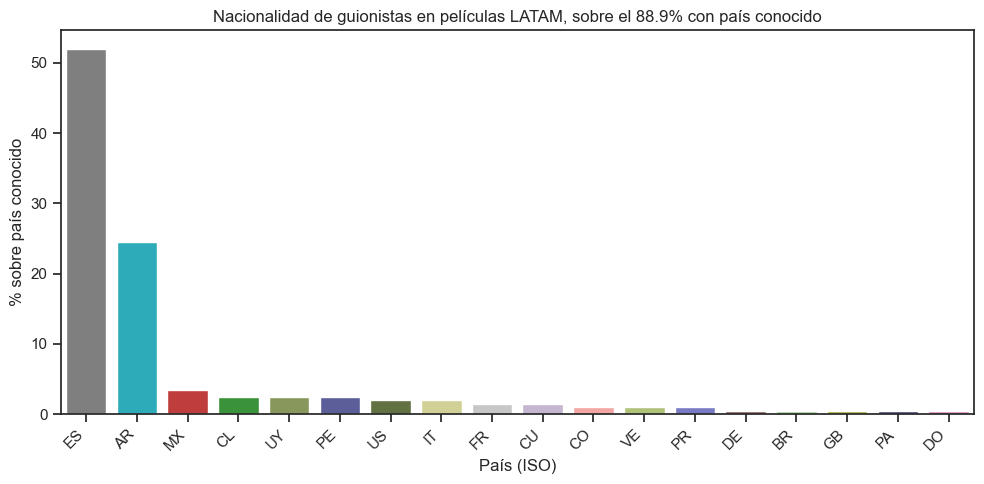

In [101]:
pct_pais_guion_dist = (guion_latam['pais'].value_counts(normalize=True) * 100).round(1).reset_index()
pct_pais_guion_dist.columns = ['pais', 'porcentaje']

plt.figure(figsize=(10, 5))
sns.barplot(data=pct_pais_guion_dist, x='pais', y='porcentaje',
            hue='pais', palette=COLORES_PAISES, legend=False)
plt.ylabel('% sobre país conocido')
plt.xlabel('País (ISO)')
plt.title(f'Nacionalidad de guionistas en películas LATAM, sobre el {pct_pais_guion}% con país conocido')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
guardar_grafico('guion_latam_pct_pais')
plt.show()


**Lectura:** distribución de nacionalidades entre los guionistas de las
películas con participación LATAM -- naturalmente `ES` domina (son
coproducciones con España), pero interesa comprobar cuánto peso real
tienen las nacionalidades latinoamericanas mismas.

### Distribución de guionistas latinoamericanos por país y sexo

Guardado: ..\4 - graficos\guion_latam_pais_sexo_dumbbell.png


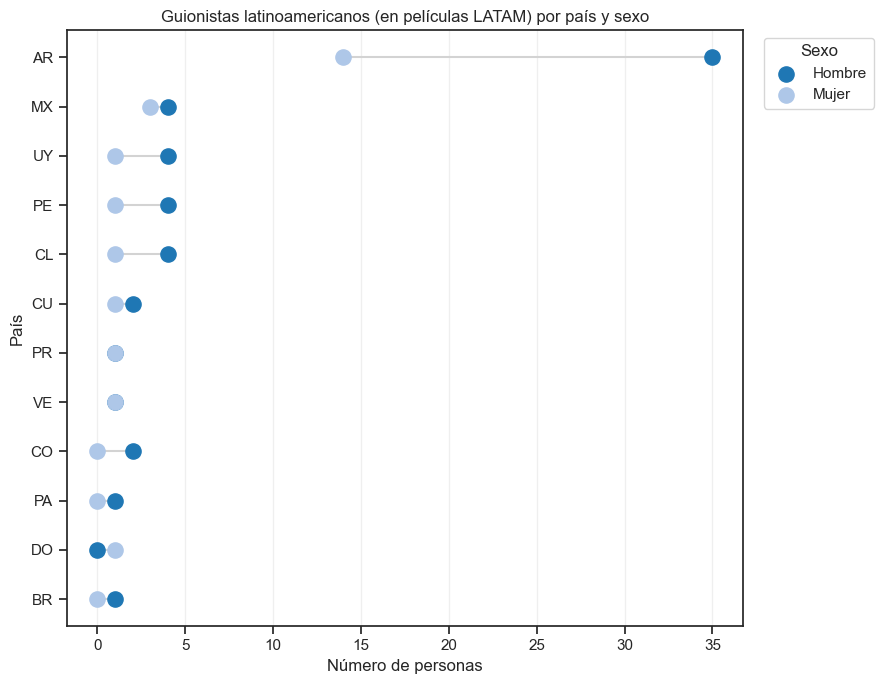

In [102]:
guion_latam_pais_sexo = consultar("""
    SELECT g.pais, g.sexo, COUNT(DISTINCT g.guionista_id) AS num_personas
    FROM guion g
    JOIN peliculas_guion pg ON pg.guionista_id = g.guionista_id
    JOIN vista_latam v ON v.pelicula_id = pg.pelicula_id
    WHERE g.pais IN ('MX','AR','CO','CL','DO','UY','GT','PE','PA','BR','CU','PR','CR','EC','NI','VE','PY')
      AND g.sexo IS NOT NULL
    GROUP BY g.pais, g.sexo
""")

pivot = guion_latam_pais_sexo.pivot(index='pais', columns='sexo', values='num_personas').fillna(0)
for col in ('hombre', 'mujer'):
    if col not in pivot.columns:
        pivot[col] = 0
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total')

fig, ax = plt.subplots(figsize=(9, 7))
for i, pais in enumerate(pivot.index):
    ax.plot([pivot.loc[pais, 'hombre'], pivot.loc[pais, 'mujer']], [i, i], color='lightgray', zorder=1, linewidth=1.5)
ax.scatter(pivot['hombre'], range(len(pivot)), color=COLORES_SEXO['hombre'], s=120, label='Hombre', zorder=2)
ax.scatter(pivot['mujer'], range(len(pivot)), color=COLORES_SEXO['mujer'], s=120, label='Mujer', zorder=2)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Número de personas')
ax.set_ylabel('País')
ax.set_title('Guionistas latinoamericanos (en películas LATAM) por país y sexo')
ax.legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
guardar_grafico('guion_latam_pais_sexo_dumbbell')
plt.show()


**Lectura:** el dumbbell deja ver de un vistazo tanto el volumen total por
país (posición del par de puntos) como el desequilibrio de sexo dentro de
cada uno (distancia entre los dos puntos).

### Resumen: sexo y origen latinoamericano (Guion)

Guardado: ..\4 - graficos\guion_sexo_origen_resumen.png


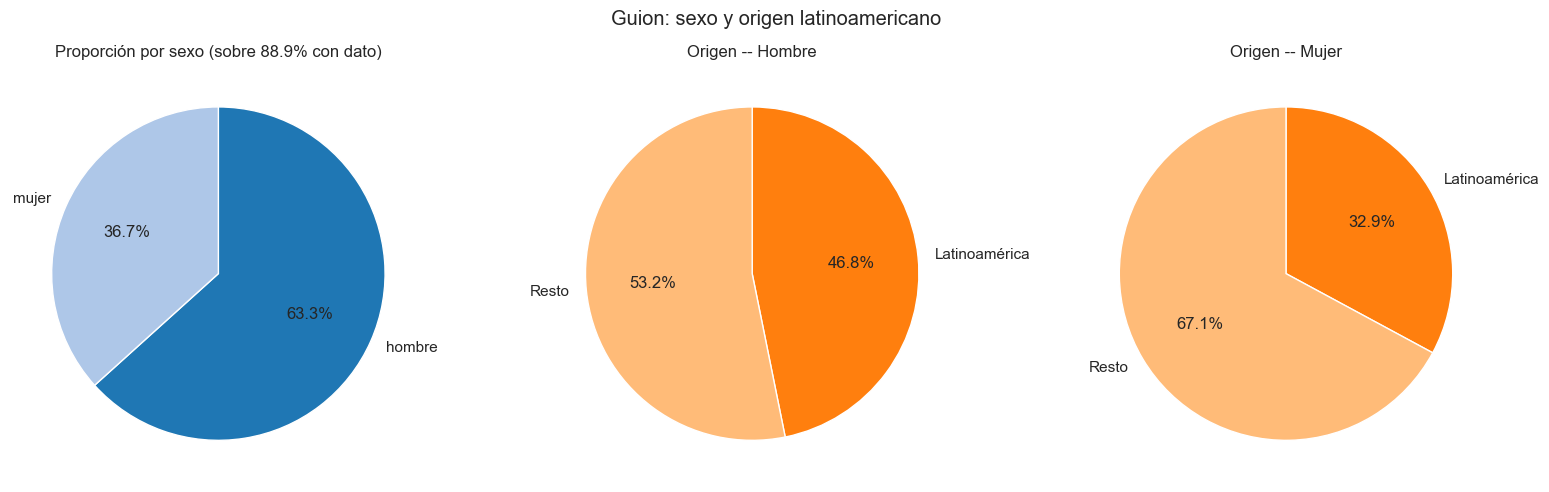

In [103]:
LATAM_ISO = {'AR','BR','CL','CO','CR','CU','DO','EC','MX','NI','PA','PE','PR','UY','VE'}

sexos_validos = ['hombre', 'mujer']
conteo_sexo = guion_latam['sexo'].value_counts().reindex(sexos_validos)

con_pais_guion_latam = guion_latam.dropna(subset=['pais']).copy()
con_pais_guion_latam['origen'] = con_pais_guion_latam['pais'].apply(lambda p: 'Latinoamérica' if p in LATAM_ISO else 'Resto')

orden_pie = ['Latinoamérica', 'Resto']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(
    conteo_sexo, labels=conteo_sexo.index, autopct='%1.1f%%',
    colors=[COLORES_SEXO[s] for s in conteo_sexo.index],
    startangle=90, counterclock=False,
)
axes[0].set_title(f'Proporción por sexo (sobre {pct_sexo_guion}% con dato)')

for ax, sexo_val in zip(axes[1:], sexos_validos):
    datos = (
        con_pais_guion_latam[con_pais_guion_latam['sexo'] == sexo_val]['origen']
        .value_counts().reindex(orden_pie)
    )
    ax.pie(
        datos, labels=datos.index, autopct='%1.1f%%',
        colors=[COLORES_LATAM[etq] for etq in datos.index],
        startangle=90, counterclock=False,
    )
    ax.set_title(f'Origen -- {sexo_val.capitalize()}')

fig.suptitle('Guion: sexo y origen latinoamericano')
plt.tight_layout()
guardar_grafico('guion_sexo_origen_resumen')
plt.show()


**Lectura:** entre guionistas de películas LATAM, la brecha de sexo se
mantiene similar independientemente del origen (43,3% de los hombres son
de origen latinoamericano, 42,6% de las mujeres -- prácticamente igual).
No hay indicio de que ser de origen LATAM se asocie a más o menos
desequilibrio de sexo dentro de este corpus. **Nota**: 1 persona con sexo
`no_binario` queda fuera de los dos pies de origen (solo hombre/mujer),
aunque sí cuenta en el "% con dato" del primer pie.

### DIRECCIÓN

In [104]:
direccion_latam = consultar("""
    SELECT DISTINCT d.director_id, d.pais, d.sexo
    FROM direccion d
    JOIN peliculas_direccion pd ON pd.director_id = d.director_id
    JOIN vista_latam v ON v.pelicula_id = pd.pelicula_id
""")

pct_pais_direccion = (direccion_latam['pais'].notna().mean() * 100).round(1)
pct_sexo_direccion = (direccion_latam['sexo'].notna().mean() * 100).round(1)
print(f"Dirección (personas en películas LATAM) — cobertura país: {pct_pais_direccion}% "
      f"({direccion_latam['pais'].notna().sum()}/{len(direccion_latam)})")
print(f"Dirección — cobertura sexo: {pct_sexo_direccion}% ({direccion_latam['sexo'].notna().sum()}/{len(direccion_latam)})")


Dirección (personas en películas LATAM) — cobertura país: 93.4% (141/151)
Dirección — cobertura sexo: 93.4% (141/151)


### Distribución de directores latinoamericanos por país y sexo

Guardado: ..\4 - graficos\direccion_latam_pais_sexo_dumbbell.png


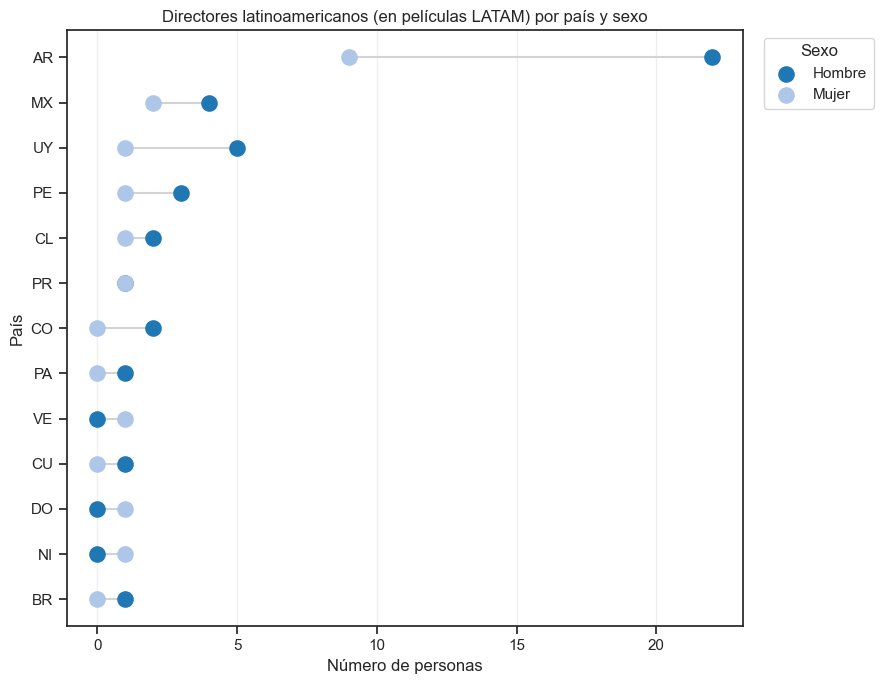

In [105]:
direccion_latam_pais_sexo = consultar("""
    SELECT d.pais, d.sexo, COUNT(DISTINCT d.director_id) AS num_personas
    FROM direccion d
    JOIN peliculas_direccion pd ON pd.director_id = d.director_id
    JOIN vista_latam v ON v.pelicula_id = pd.pelicula_id
    WHERE d.pais IN ('MX','AR','CO','CL','DO','UY','GT','PE','PA','BR','CU','PR','CR','EC','NI','VE','PY')
      AND d.sexo IS NOT NULL
    GROUP BY d.pais, d.sexo
""")

pivot = direccion_latam_pais_sexo.pivot(index='pais', columns='sexo', values='num_personas').fillna(0)
for col in ('hombre', 'mujer'):
    if col not in pivot.columns:
        pivot[col] = 0
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total')

fig, ax = plt.subplots(figsize=(9, 7))
for i, pais in enumerate(pivot.index):
    ax.plot([pivot.loc[pais, 'hombre'], pivot.loc[pais, 'mujer']], [i, i], color='lightgray', zorder=1, linewidth=1.5)
ax.scatter(pivot['hombre'], range(len(pivot)), color=COLORES_SEXO['hombre'], s=120, label='Hombre', zorder=2)
ax.scatter(pivot['mujer'], range(len(pivot)), color=COLORES_SEXO['mujer'], s=120, label='Mujer', zorder=2)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Número de personas')
ax.set_ylabel('País')
ax.set_title('Directores latinoamericanos (en películas LATAM) por país y sexo')
ax.legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
guardar_grafico('direccion_latam_pais_sexo_dumbbell')
plt.show()


**Lectura:** mismo tipo de comparación que en guion -- el desequilibrio de
sexo en dirección suele ser más marcado que en guion en la mayoría de
cinematografías, vale la pena comparar ambos gráficos lado a lado.

### Resumen: sexo y origen latinoamericano (Dirección)

Guardado: ..\4 - graficos\dirección_sexo_origen_resumen.png


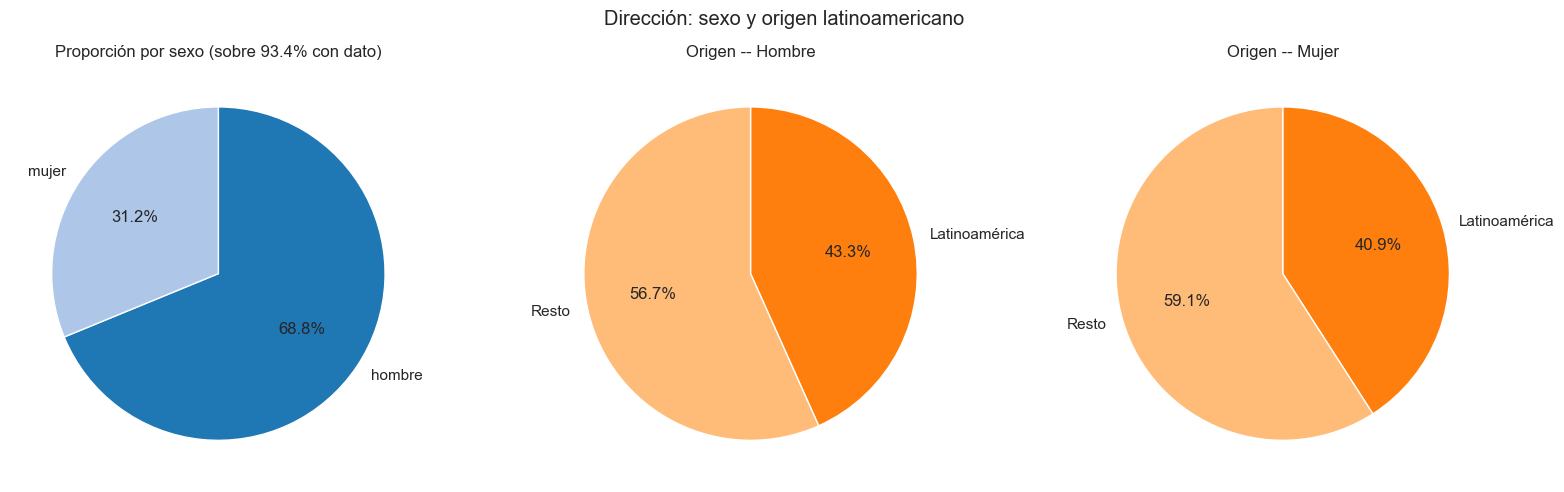

In [106]:
LATAM_ISO = {'AR','BR','CL','CO','CR','CU','DO','EC','MX','NI','PA','PE','PR','UY','VE'}

sexos_validos = ['hombre', 'mujer']
conteo_sexo = direccion_latam['sexo'].value_counts().reindex(sexos_validos)

con_pais_direccion_latam = direccion_latam.dropna(subset=['pais']).copy()
con_pais_direccion_latam['origen'] = con_pais_direccion_latam['pais'].apply(lambda p: 'Latinoamérica' if p in LATAM_ISO else 'Resto')

orden_pie = ['Latinoamérica', 'Resto']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(
    conteo_sexo, labels=conteo_sexo.index, autopct='%1.1f%%',
    colors=[COLORES_SEXO[s] for s in conteo_sexo.index],
    startangle=90, counterclock=False,
)
axes[0].set_title(f'Proporción por sexo (sobre {pct_sexo_direccion}% con dato)')

for ax, sexo_val in zip(axes[1:], sexos_validos):
    datos = (
        con_pais_direccion_latam[con_pais_direccion_latam['sexo'] == sexo_val]['origen']
        .value_counts().reindex(orden_pie)
    )
    ax.pie(
        datos, labels=datos.index, autopct='%1.1f%%',
        colors=[COLORES_LATAM[etq] for etq in datos.index],
        startangle=90, counterclock=False,
    )
    ax.set_title(f'Origen -- {sexo_val.capitalize()}')

fig.suptitle('Dirección: sexo y origen latinoamericano')
plt.tight_layout()
guardar_grafico('dirección_sexo_origen_resumen')
plt.show()


**Lectura:** mismo contraste para dirección -- compara esta cifra con la
de guion para ver si el origen LATAM pesa de forma distinta en el
desequilibrio de sexo según el rol (dirección vs. guion).

### Guionistas y directores latinoamericanos, por sexo

Guardado: ..\4 - graficos\guion_direccion_latam_por_sexo.png


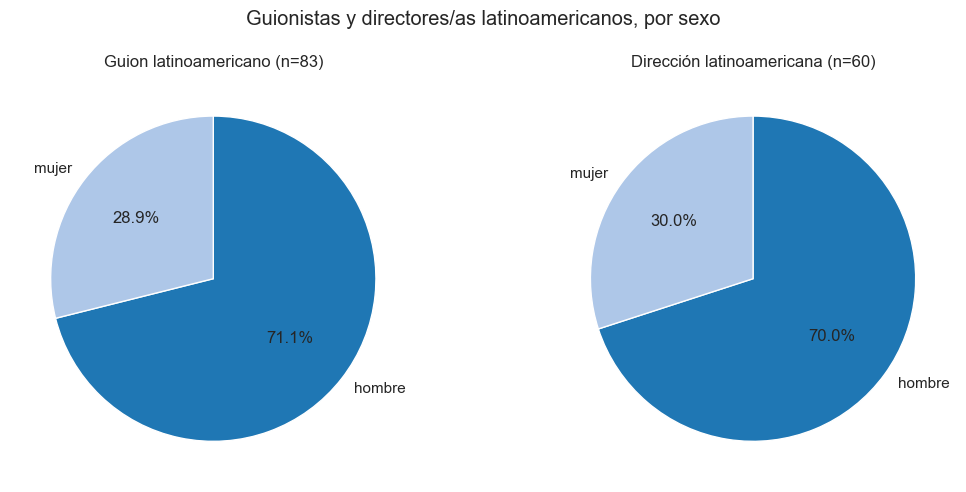

In [107]:
LATAM_ISO = {'AR','BR','CL','CO','CR','CU','DO','EC','MX','NI','PA','PE','PR','UY','VE'}
sexos_validos = ['hombre', 'mujer']

guion_latam_origen = guion_latam[guion_latam['pais'].isin(LATAM_ISO)]
direccion_latam_origen = direccion_latam[direccion_latam['pais'].isin(LATAM_ISO)]

conteo_guion = guion_latam_origen['sexo'].value_counts().reindex(sexos_validos)
conteo_direccion = direccion_latam_origen['sexo'].value_counts().reindex(sexos_validos)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].pie(
    conteo_guion, labels=conteo_guion.index, autopct='%1.1f%%',
    colors=[COLORES_SEXO[s] for s in conteo_guion.index],
    startangle=90, counterclock=False,
)
axes[0].set_title(f'Guion latinoamericano (n={int(conteo_guion.sum())})')

axes[1].pie(
    conteo_direccion, labels=conteo_direccion.index, autopct='%1.1f%%',
    colors=[COLORES_SEXO[s] for s in conteo_direccion.index],
    startangle=90, counterclock=False,
)
axes[1].set_title(f'Dirección latinoamericana (n={int(conteo_direccion.sum())})')

fig.suptitle('Guionistas y directores/as latinoamericanos, por sexo')
plt.tight_layout()
guardar_grafico('guion_direccion_latam_por_sexo')
plt.show()


**Lectura:** el desequilibrio de sexo entre guionistas y directores/as
LATAM es de magnitud parecida en ambos roles -- no hay indicio de que la
dirección esté notablemente más masculinizada que el guion dentro de este
subconjunto, aunque el volumen absoluto es pequeño (83 y 60 personas
respectivamente), así que un par de casos de más o de menos puede mover
el porcentaje de forma visible.

---
## 10. Países coproductores

### Géneros por país LATAM (Top 8 países)

Guardado: ..\4 - graficos\genero_por_pais_heatmap.png


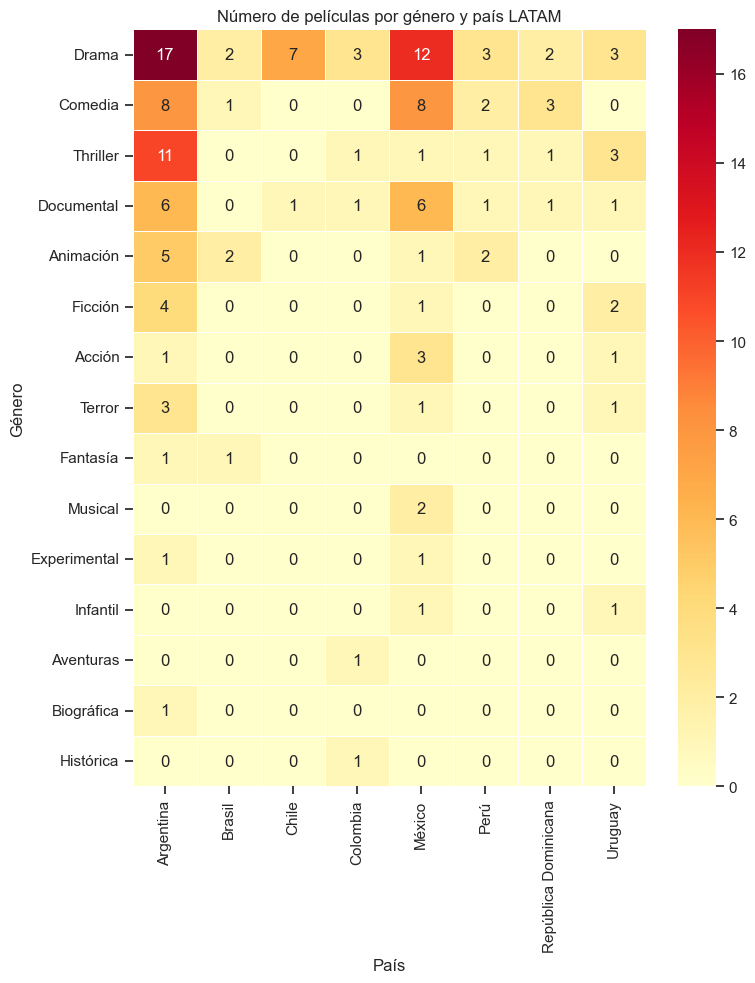

In [108]:
top8_paises = consultar("""
    SELECT pa.nombre AS pais, COUNT(*) AS num_peliculas
    FROM participacion_pais pp
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre
    ORDER BY num_peliculas DESC
    LIMIT 8
""")['pais'].tolist()

placeholders = ", ".join([f"'{p}'" for p in top8_paises])
pais_genero = consultar(f"""
    SELECT pa.nombre AS pais, gp.genero_padre, COUNT(*) AS num_peliculas
    FROM participacion_pais pp
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = pp.pelicula_id
    WHERE pa.nombre IN ({placeholders})
    GROUP BY pa.nombre, gp.genero_padre
""")

pivot = pais_genero.pivot(index='genero_padre', columns='pais', values='num_peliculas').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Número de películas por género y país LATAM')
plt.xlabel('País')
plt.ylabel('Género')
plt.tight_layout()
guardar_grafico('genero_por_pais_heatmap')
plt.show()


**Lectura:** los países con mayor participación (Argentina y México, de
forma consistente) lo hacen en una variedad amplia de géneros; los países
con menos participación suelen concentrarse en 1-2 categorías.

### Géneros ponderados por participación: Argentina vs. México

Guardado: ..\4 - graficos\participacion_ar_mx_por_genero.png


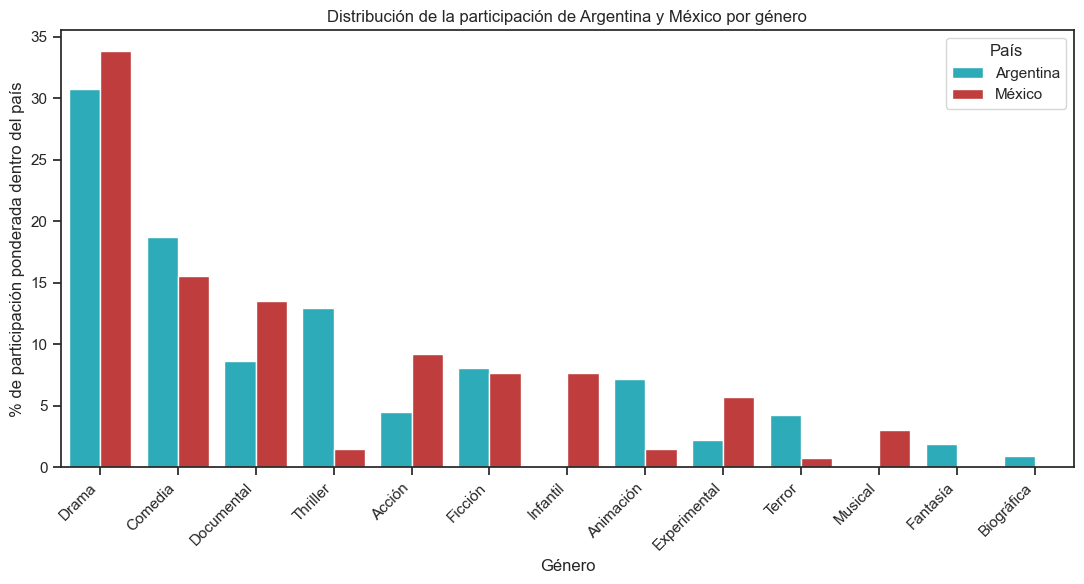

In [109]:
generos_ar_mx = consultar("""
    SELECT pa.nombre AS pais, gp.genero_padre,
           COUNT(DISTINCT pp.pelicula_id) AS num_peliculas,
           SUM(pp.porcentaje) AS porcentaje_total
    FROM participacion_pais pp
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.nombre IN ('Argentina', 'México')
    JOIN peliculas_generos_padre gp ON gp.pelicula_id = pp.pelicula_id
    GROUP BY pa.nombre, gp.genero_padre
""")
generos_ar_mx['pct_sobre_pais'] = (
    generos_ar_mx.groupby('pais')['porcentaje_total'].transform(lambda x: x / x.sum() * 100)
).round(2)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=generos_ar_mx.sort_values('pct_sobre_pais', ascending=False),
    x='genero_padre', y='pct_sobre_pais', hue='pais', hue_order=['Argentina', 'México'],
    palette=COLORES_PAISES_NOMBRE,
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('% de participación ponderada dentro del país')
plt.xlabel('Género')
plt.title('Distribución de la participación de Argentina y México por género')
plt.legend(title='País')
plt.tight_layout()
guardar_grafico('participacion_ar_mx_por_genero')
plt.show()


**Lectura:** ponderar por `porcentaje` de participación (no solo contar
películas) evita que una coproducción minoritaria (ej. 10%) pese igual que
una mayoritaria (90%) al comparar el perfil de género de cada país.

### Evolución temporal por país (Top 2)

Guardado: ..\4 - graficos\evolucion_top2_paises_por_anio.png


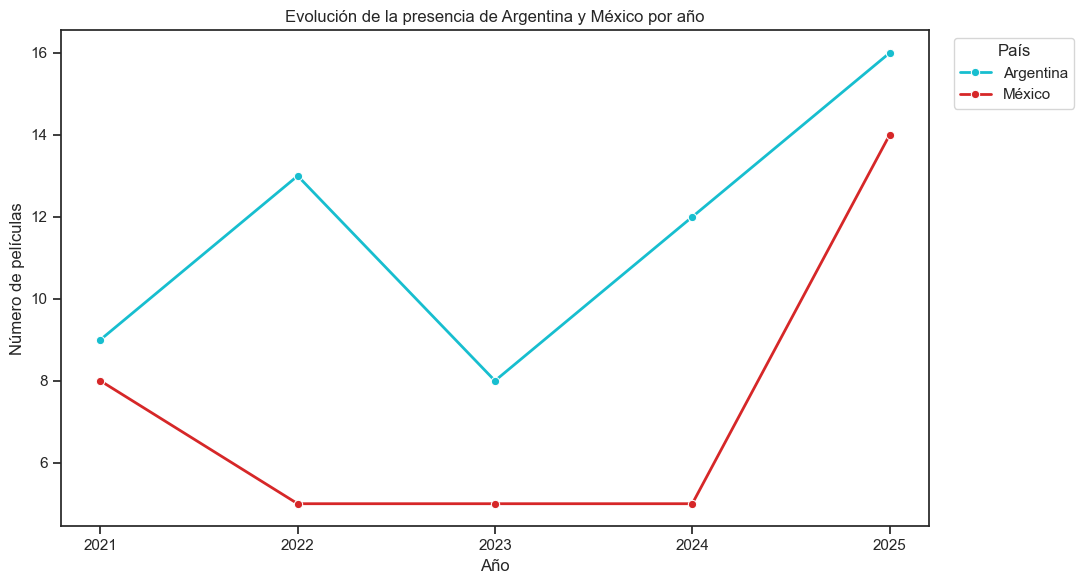

In [110]:
top2_paises = consultar("""
    SELECT pa.nombre AS pais, COUNT(*) AS num
    FROM participacion_pais pp
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre ORDER BY num DESC LIMIT 2
""")['pais'].tolist()

placeholders = ", ".join([f"'{p}'" for p in top2_paises])
evolucion_paises = consultar(f"""
    SELECT v.anio, pa.nombre AS pais, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.nombre IN ({placeholders})
    WHERE v.anio BETWEEN 2021 AND 2025
    GROUP BY v.anio, pa.nombre
""")

plt.figure(figsize=(11, 6))
sns.lineplot(data=evolucion_paises, x='anio', y='num_peliculas', hue='pais',
             marker='o', linewidth=2, hue_order=top2_paises, palette=COLORES_PAISES_NOMBRE)
plt.xticks(sorted(evolucion_paises['anio'].unique()))
plt.xlabel('Año')
plt.ylabel('Número de películas')
plt.title(f'Evolución de la presencia de {top2_paises[0]} y {top2_paises[1]} por año')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('evolucion_top2_paises_por_anio')
plt.show()


**Lectura:** los dos países con mayor participación no necesariamente
crecen o caen juntos año a año -- vale la pena ver si uno compensa al otro
o si ambos se mueven con el ciclo general del corpus.

### Recaudación prorrateada por país

In [111]:
recaudacion_pais = consultar("""
    SELECT pa.nombre AS pais,
           COUNT(DISTINCT pp.pelicula_id) AS num_peliculas,
           SUM(v.recaudacion_total) AS recaudacion_total,
           SUM(v.recaudacion_total * pp.porcentaje / 100) AS recaudacion_prorrateada_total
    FROM vista_latam v
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre
    ORDER BY recaudacion_prorrateada_total DESC
""")
recaudacion_pais["recaudacion_prorrateada_pct"] = (
    recaudacion_pais["recaudacion_prorrateada_total"] / recaudacion_pais["recaudacion_total"] * 100
).round(1)
recaudacion_pais.round(0)

,pais,num_peliculas,recaudacion_total,recaudacion_prorrateada_total,recaudacion_prorrateada_pct
0,México,37,"16,577,904.00","3,356,699.00",20.00
1,Argentina,58,"4,732,613.00","1,097,934.00",23.00
2,Colombia,7,"1,262,772.00","256,625.00",20.00
3,República Dominicana,7,"811,602.00","187,541.00",23.00
4,Chile,8,"571,608.00","139,485.00",24.00
5,Perú,9,"675,794.00","124,552.00",18.00
6,Uruguay,12,"531,146.00","108,424.00",20.00
7,Panamá,4,"73,698.00","16,218.00",22.00
8,Brasil,6,"41,498.00","9,371.00",23.00
9,Venezuela,1,"28,500.00","5,700.00",20.00


**Lectura:** reparte la recaudación de cada película entre sus países
coproductores según su `porcentaje` real de participación

### Cuadrantes: volumen de títulos vs. recaudación, por país

Nñumero de títulos que coloca cada país LATAM (eje X) frente a cuánta
recaudación aportan esos títulos (eje Y) -- el tamaño de la burbuja es el
`porcentaje` medio de participación de ese país en sus coproducciones.

Guardado: ..\4 - graficos\cuadrantes_pais_titulos_vs_recaudacion.png


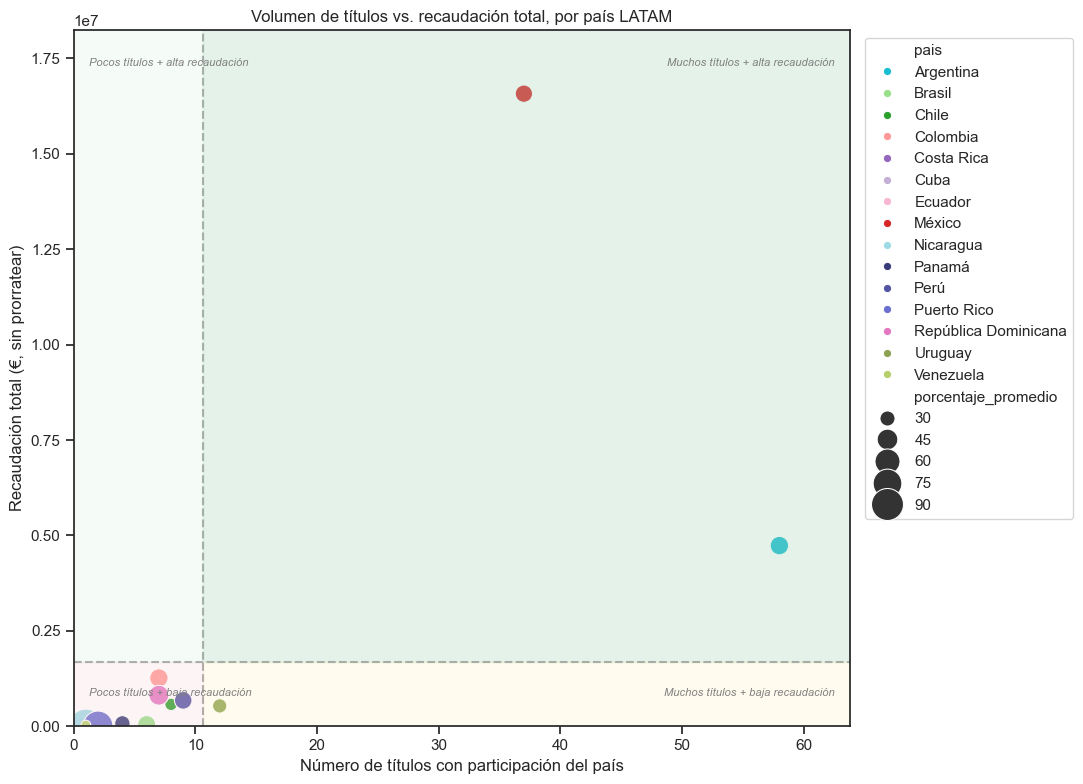

In [112]:
cuadrantes_pais = consultar("""
    SELECT pa.nombre AS pais,
           COUNT(DISTINCT pp.pelicula_id) AS num_peliculas,
           SUM(v.recaudacion_total) AS recaudacion_total,
           AVG(pp.porcentaje) AS porcentaje_promedio
    FROM vista_latam v
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre
""")

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=cuadrantes_pais, x='num_peliculas', y='recaudacion_total',
    hue='pais', palette=COLORES_PAISES_NOMBRE,
    size='porcentaje_promedio', sizes=(50, 600)
)

media_x = cuadrantes_pais['num_peliculas'].mean()
media_y = cuadrantes_pais['recaudacion_total'].mean()
plt.axvline(media_x, linestyle='--', color='gray', alpha=0.6)
plt.axhline(media_y, linestyle='--', color='gray', alpha=0.6)

xmin, xmax = 0, cuadrantes_pais['num_peliculas'].max() * 1.1
ymin, ymax = 0, cuadrantes_pais['recaudacion_total'].max() * 1.1

plt.text(xmax * 0.98, ymax * 0.96, 'Muchos títulos + alta recaudación', ha='right', va='top', fontsize=8, color='gray', style='italic')
plt.fill_between([media_x, xmax], media_y, ymax, color="#A8D5BA", alpha=0.30)

plt.text(xmin + xmax * 0.02, ymax * 0.96, 'Pocos títulos + alta recaudación', ha='left', va='top', fontsize=8, color='gray', style='italic')
plt.fill_between([xmin, media_x], media_y, ymax, color="#D8F3DC", alpha=0.25)

plt.text(xmax * 0.98, ymax * 0.04, 'Muchos títulos + baja recaudación', ha='right', va='bottom', fontsize=8, color='gray', style='italic')
plt.fill_between([media_x, xmax], ymin, media_y, color="#FFF3BF", alpha=0.25)

plt.text(xmin + xmax * 0.02, ymax * 0.04, 'Pocos títulos + baja recaudación', ha='left', va='bottom', fontsize=8, color='gray', style='italic')
plt.fill_between([xmin, media_x], ymin, media_y, color="#F8D7DA", alpha=0.25)

plt.xlabel('Número de títulos con participación del país')
plt.ylabel('Recaudación total (€, sin prorratear)')
plt.title('Volumen de títulos vs. recaudación total, por país LATAM')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.tight_layout()
guardar_grafico('cuadrantes_pais_titulos_vs_recaudacion')
plt.show()

**Lectura:** los países en el cuadrante superior derecho (muchos títulos,
alta recaudación) son los socios LATAM más consolidados; los
del cuadrante superior izquierdo aportan poco volumen pero con retorno
económico alto por título -- vale la pena mirar si su burbuja también es
grande (mucho `porcentaje` medio de participación, no solo presencia
simbólica).

---
## 11. Empresas productoras

Dimensión sin antecedente en el proyecto anterior -- no existía este dato.
`empresas_productoras` no tiene país como columna propia (vive en la tabla
puente `peliculas_empresas_productoras.pais_id`), pero se comprobó que
cada empresa tiene siempre un único país asociado en todas sus apariciones
(0 de 2279 con más de uno), así que el `JOIN` es fiable.

### 11.1 Empresas productoras más activas

Guardado: ..\4 - graficos\top10_empresas_productoras_activas.png


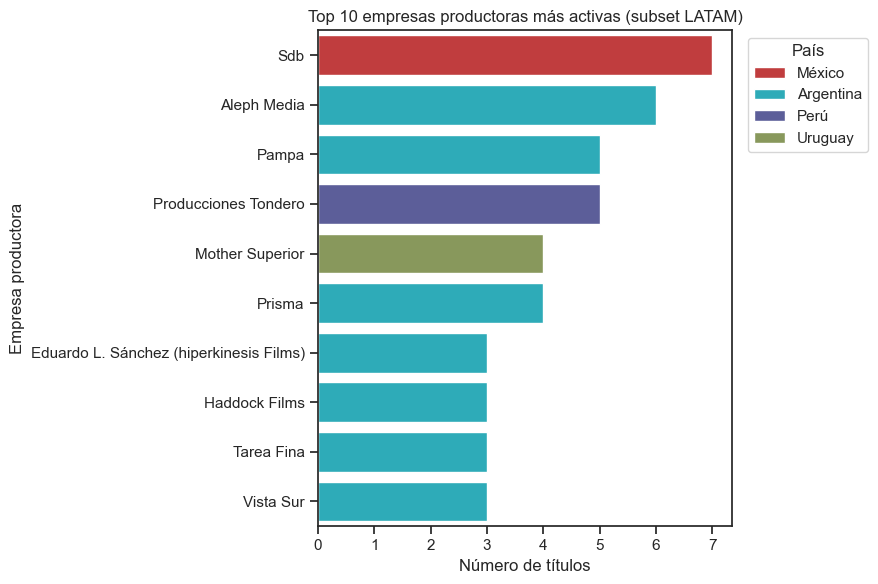

In [113]:
ranking_empresas = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.nombre, pa.nombre
    ORDER BY num_peliculas DESC
""")

top10_empresas = ranking_empresas.head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=top10_empresas, y='empresa', x='num_peliculas', hue='pais', palette=COLORES_PAISES_NOMBRE, dodge=False)
plt.xlabel('Número de títulos')
plt.ylabel('Empresa productora')
plt.title('Top 10 empresas productoras más activas (subset LATAM)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('top10_empresas_productoras_activas')
plt.show()

**Lectura:** el volumen está bastante repartido -- la empresa más activa
(7 títulos) no domina de forma abrumadora como sí pasaba con Castelao
entre las distribuidoras. Conviene mirar también si el país de la empresa
líder coincide con el país que más títulos aporta en general (Argentina y
México), o si hay sorpresas.

In [114]:
empresas_mas_activas = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais,
           COUNT(DISTINCT pep.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.empresa_id, ep.nombre, pa.nombre
    ORDER BY num_peliculas DESC
    LIMIT 15
""")
empresas_mas_activas

,empresa,pais,num_peliculas
0,Sdb,México,7
1,Aleph Media,Argentina,6
2,Producciones Tondero,Perú,5
3,Pampa,Argentina,5
4,Mother Superior,Uruguay,4
5,Prisma,Argentina,4
6,Vista Sur,Argentina,3
7,Tarea Fina,Argentina,3
8,Haddock Films,Argentina,3
9,Eduardo L. Sánchez (hiperkinesis Films),Argentina,3


In [115]:
recurrencia_por_pais = consultar("""
    SELECT pais,
           COUNT(*) AS num_empresas,
           SUM(CASE WHEN num_peliculas > 1 THEN 1 ELSE 0 END) AS empresas_recurrentes,
           ROUND(SUM(CASE WHEN num_peliculas > 1 THEN 1 ELSE 0 END) / COUNT(*) * 100, 1) AS pct_recurrencia
    FROM (
        SELECT pa.nombre AS pais, pep.empresa_id,
               COUNT(DISTINCT pep.pelicula_id) AS num_peliculas
        FROM vista_latam v
        JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
        JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
        GROUP BY pa.nombre, pep.empresa_id
    ) AS empresa_pais_conteo
    GROUP BY pais
    ORDER BY num_empresas DESC
""")
recurrencia_por_pais

,pais,num_empresas,empresas_recurrentes,pct_recurrencia
0,Argentina,56,11.00,19.60
1,México,32,3.00,9.40
2,Uruguay,9,1.00,11.10
3,Chile,8,0.00,0.00
4,República Dominicana,7,0.00,0.00
5,Colombia,6,0.00,0.00
6,Brasil,5,0.00,0.00
7,Perú,5,1.00,20.00
8,Cuba,4,0.00,0.00
9,Panamá,4,0.00,0.00


### Evolución por año (Top 5 empresas)

Guardado: ..\4 - graficos\evolucion_top5_empresas_productoras.png


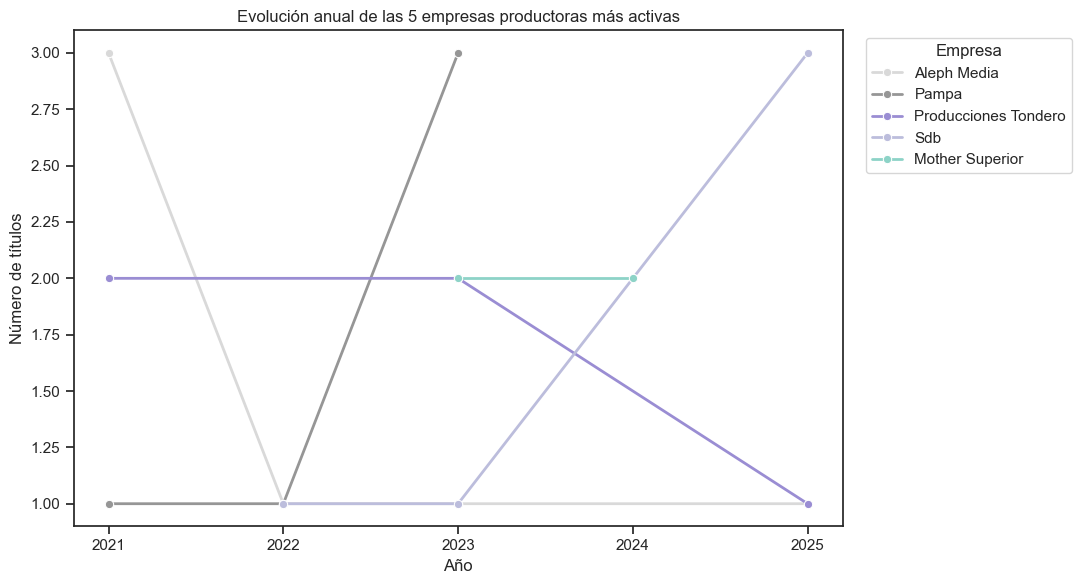

In [119]:
top5_empresas = ranking_empresas.head(5)['empresa'].tolist()
placeholders = ", ".join([f"'{e}'" for e in top5_empresas])

evolucion_empresas = consultar(f"""
    SELECT v.anio, ep.nombre AS empresa, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    WHERE ep.nombre IN ({placeholders}) AND v.anio BETWEEN 2021 AND 2025
    GROUP BY v.anio, ep.nombre
""")

plt.figure(figsize=(11, 6))
sns.lineplot(data=evolucion_empresas, x='anio', y='num_peliculas', hue='empresa', palette=COLORES_EMPRESAS, marker='o', linewidth=2)
plt.xticks(sorted(evolucion_empresas['anio'].unique()))
plt.xlabel('Año')
plt.ylabel('Número de títulos')
plt.title('Evolución anual de las 5 empresas productoras más activas')
plt.legend(title='Empresa', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('evolucion_top5_empresas_productoras')
plt.show()


**Lectura:** a diferencia de una distribuidora (que estrena muchos
títulos por catálogo), una empresa productora rara vez concentra varios
títulos en el mismo año -- si ves picos aislados en vez de una línea
sostenida, es la norma esperable, no una anomalía.

### Evolución por año (Top 5 empresas por recaudación)

Cambio de criterio respecto al Top 10 de la sección anterior: aquí no es
"quién hizo más títulos", sino "quién generó más recaudación en total" --
la pregunta es si ese dinero vino de un solo año (flor de un día) o se
repartió de forma sostenida.

Guardado: ..\4 - graficos\evolucion_top5_empresas_por_recaudacion.png


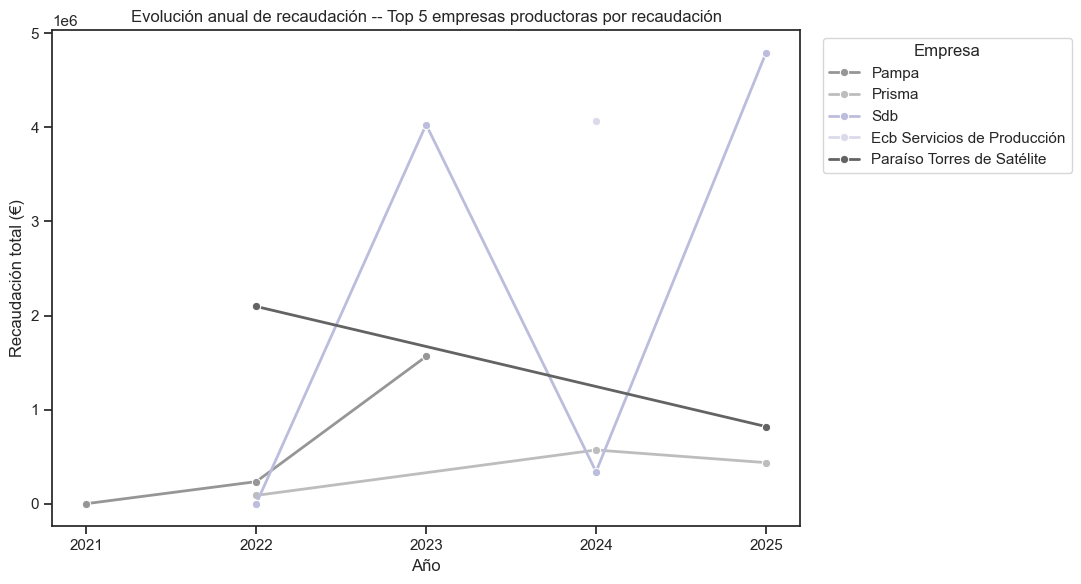

In [120]:
ranking_empresas_recaudacion = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais, SUM(v.recaudacion_total) AS recaudacion_total
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.nombre, pa.nombre
    ORDER BY recaudacion_total DESC
""")

top5_empresas_recaudacion = ranking_empresas_recaudacion.head(5)['empresa'].tolist()
placeholders = ", ".join([f"'{e}'" for e in top5_empresas_recaudacion])

evolucion_empresas_recaudacion = consultar(f"""
    SELECT v.anio, ep.nombre AS empresa, SUM(v.recaudacion_total) AS recaudacion_total
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    WHERE ep.nombre IN ({placeholders}) AND v.anio BETWEEN 2021 AND 2025
    GROUP BY v.anio, ep.nombre
""")

plt.figure(figsize=(11, 6))
sns.lineplot(data=evolucion_empresas_recaudacion, x='anio', y='recaudacion_total', hue='empresa', palette=COLORES_EMPRESAS, marker='o', linewidth=2)
plt.xticks(sorted(evolucion_empresas_recaudacion['anio'].unique()))
plt.xlabel('Año')
plt.ylabel('Recaudación total (€)')
plt.title('Evolución anual de recaudación -- Top 5 empresas productoras por recaudación')
plt.legend(title='Empresa', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('evolucion_top5_empresas_por_recaudacion')
plt.show()


**Lectura:** aquí es donde se ve si una empresa fue "flor de un día" --
un pico único en un solo año (toda su recaudación viene de un título de
éxito puntual) frente a una empresa con presencia repartida en varios
años. Como la mayoría de estas empresas tienen pocos títulos en total
(sección 11.2: solo el 11,8% repite), es probable que varias de las
Top 5 por recaudación muestren justo ese patrón de pico único -- no sería
un error de los datos, sino el reflejo de que el gran retorno económico
de un país LATAM concreto puede depender de un solo título excepcional,
no de una empresa consolidada.

### Evolución por año (Top 5 empresas por recurrencia)

Mismas 5 empresas del Top 10 de la sección 11.1 (por número de títulos, no
por dinero) -- complementa la vista anterior: aquí se ve si el volumen de
títulos también se sostuvo en el tiempo, o se concentró en pocos años.

Guardado: ..\4 - graficos\evolucion_top5_empresas_por_recurrencia.png


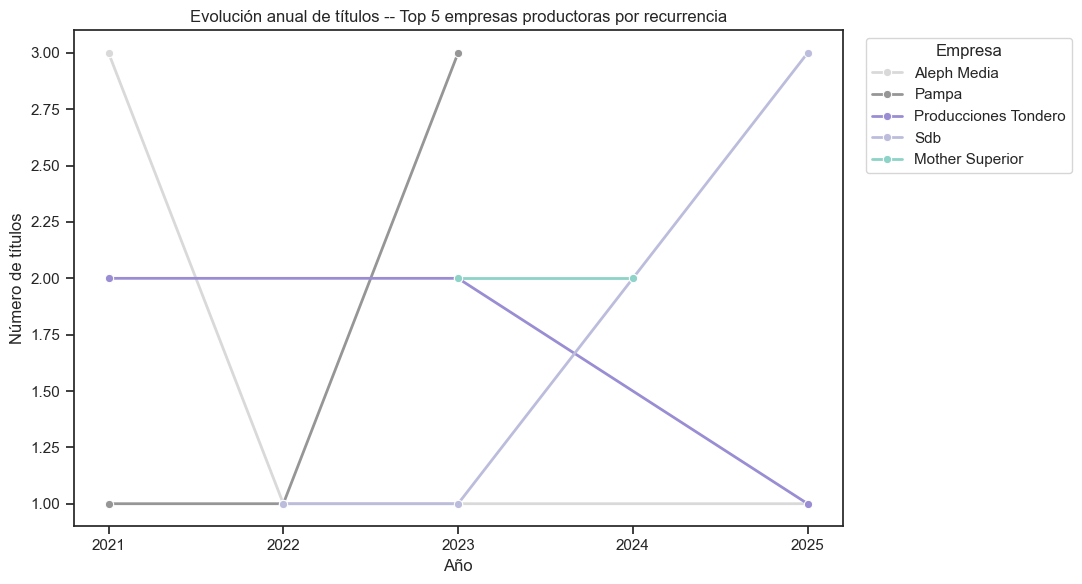

In [121]:
top5_empresas_recurrencia = ranking_empresas.head(5)['empresa'].tolist()
placeholders = ", ".join([f"'{e}'" for e in top5_empresas_recurrencia])

evolucion_empresas_recurrencia = consultar(f"""
    SELECT v.anio, ep.nombre AS empresa, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    WHERE ep.nombre IN ({placeholders}) AND v.anio BETWEEN 2021 AND 2025
    GROUP BY v.anio, ep.nombre
""")

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=evolucion_empresas_recurrencia, x='anio', y='num_peliculas',
    hue='empresa', palette=COLORES_EMPRESAS, marker='o', linewidth=2,
)
plt.xticks(sorted(evolucion_empresas_recurrencia['anio'].unique()))
plt.xlabel('Año')
plt.ylabel('Número de títulos')
plt.title('Evolución anual de títulos -- Top 5 empresas productoras por recurrencia')
plt.legend(title='Empresa', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('evolucion_top5_empresas_por_recurrencia')
plt.show()


**Lectura:** a diferencia del gráfico por recaudación (donde varias
empresas mostraban un pico único de "flor de un día"), aquí se espera ver
algo más repartido en el tiempo -- son, por definición, las empresas con
más títulos totales, así que su presencia debería notarse en más de un
año, aunque no necesariamente de forma perfectamente uniforme.

### 11.2 Recurrencia -- empresas que repiten

Caso que motivó esta sección: Paraíso Torres de Satélite hizo *Voy a
pasármelo bien* y, más tarde, *Voy a pasármelo mejor* -- una relación de
coproducción que se sostiene en el tiempo, no un título aislado.

In [122]:
recurrencia_empresas = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.nombre, pa.nombre
""")

repiten = (recurrencia_empresas['num_peliculas'] > 1).sum()
total = len(recurrencia_empresas)
print(f"Empresas que repiten (>1 título): {repiten} / {total} ({repiten/total*100:.1f}%)")
print()
recurrencia_empresas[recurrencia_empresas['num_peliculas'] > 1].sort_values('num_peliculas', ascending=False)


Empresas que repiten (>1 título): 16 / 143 (11.2%)



,empresa,pais,num_peliculas
125,Sdb,México,7
8,Aleph Media,Argentina,6
101,Pampa,Argentina,5
114,Producciones Tondero,Perú,5
112,Prisma,Argentina,4
94,Mother Superior,Uruguay,4
68,Haddock Films,Argentina,3
50,Eduardo L. Sánchez (hiperkinesis Films),Argentina,3
139,Vista Sur,Argentina,3
132,Tarea Fina,Argentina,3


**Lectura:** la gran mayoría de las relaciones de coproducción LATAM son
de un solo título -- la recurrencia es la excepción, no la norma. Esto en
sí mismo es un dato relevante: sugiere que la mayoría de las coproducciones
LATAM-España son proyectos puntuales, no alianzas productoras
consolidadas.

### Recurrencia por país

Guardado: ..\4 - graficos\recurrencia_empresas_por_pais.png


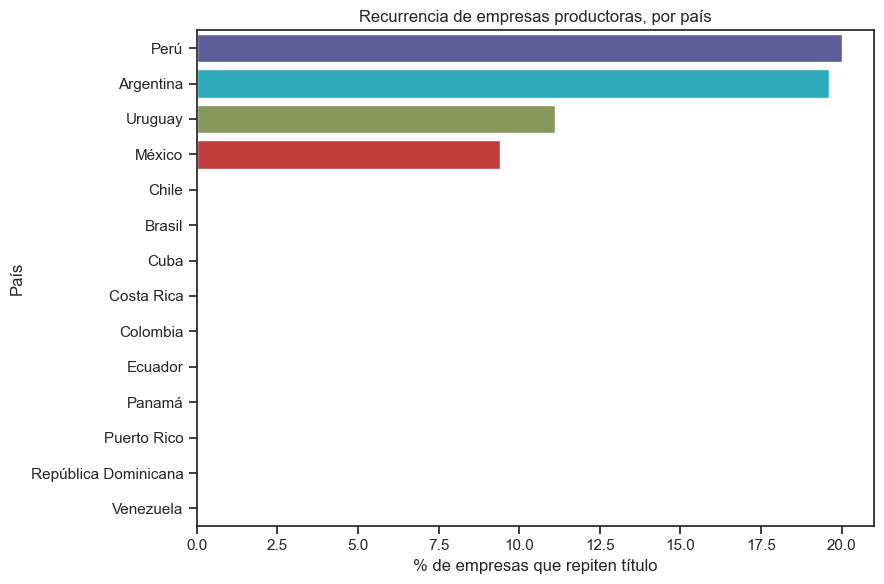

In [123]:
recurrencia_por_pais = (
    recurrencia_empresas.assign(repite=recurrencia_empresas['num_peliculas'] > 1)
    .groupby('pais')
    .agg(total_empresas=('empresa', 'count'), empresas_repiten=('repite', 'sum'))
)
recurrencia_por_pais['pct_repiten'] = (recurrencia_por_pais['empresas_repiten'] / recurrencia_por_pais['total_empresas'] * 100).round(1)
recurrencia_por_pais = recurrencia_por_pais.sort_values('pct_repiten', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=recurrencia_por_pais.reset_index(), y='pais', x='pct_repiten',
    hue='pais', palette=COLORES_PAISES_NOMBRE, legend=False,
)
plt.xlabel('% de empresas que repiten título')
plt.ylabel('País')
plt.title('Recurrencia de empresas productoras, por país')
plt.tight_layout()
guardar_grafico('recurrencia_empresas_por_pais')
plt.show()


**Lectura:** igual que con la concentración, un país con muy pocas
empresas en total puede dar un % de recurrencia poco representativo (una
sola empresa que repita ya es 50-100% del total de ese país) -- conviene
mirar esta cifra junto al número total de empresas de cada país (sección
11.3), no de forma aislada.

### 11.2b Número de empresas por país

Antes de ver la concentración relativa (11.3), la cifra absoluta: cuántas
empresas productoras distintas tiene cada país en el corpus LATAM.

Guardado: ..\4 - graficos\num_empresas_por_pais.png


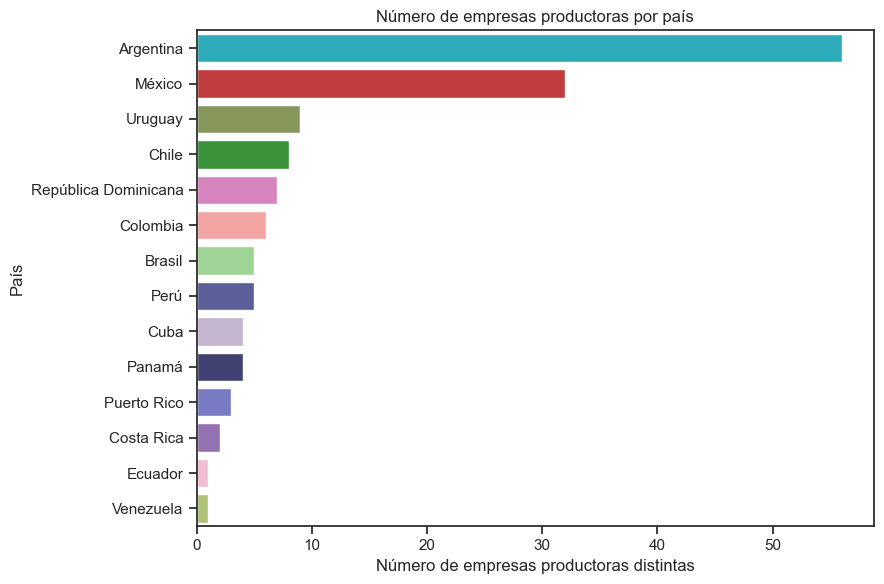

In [124]:
empresas_por_pais = consultar("""
    SELECT pa.nombre AS pais, COUNT(DISTINCT ep.empresa_id) AS num_empresas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre
    ORDER BY num_empresas DESC
""")

plt.figure(figsize=(9, 6))
sns.barplot(
    data=empresas_por_pais, y='pais', x='num_empresas',
    hue='pais', palette=COLORES_PAISES_NOMBRE, legend=False,
)
plt.xlabel('Número de empresas productoras distintas')
plt.ylabel('País')
plt.title('Número de empresas productoras por país')
plt.tight_layout()
guardar_grafico('num_empresas_por_pais')
plt.show()


**Lectura:** Argentina (56) y México (32) no solo aportan más títulos --
también tienen, de lejos, más empresas distintas participando. El resto de
países queda en un rango mucho más bajo (1-9 empresas).

### Número de empresas vs. recaudación total, por país

En vez de un índice normalizado (poco fiable con países de 1-2 empresas),
se muestran las dos magnitudes por separado -- así se ve si más empresas
se traduce en más recaudación, o si hay países con pocas empresas pero
recaudación desproporcionadamente alta (o al revés).

Guardado: ..\4 - graficos\num_empresas_vs_recaudacion_pais.png


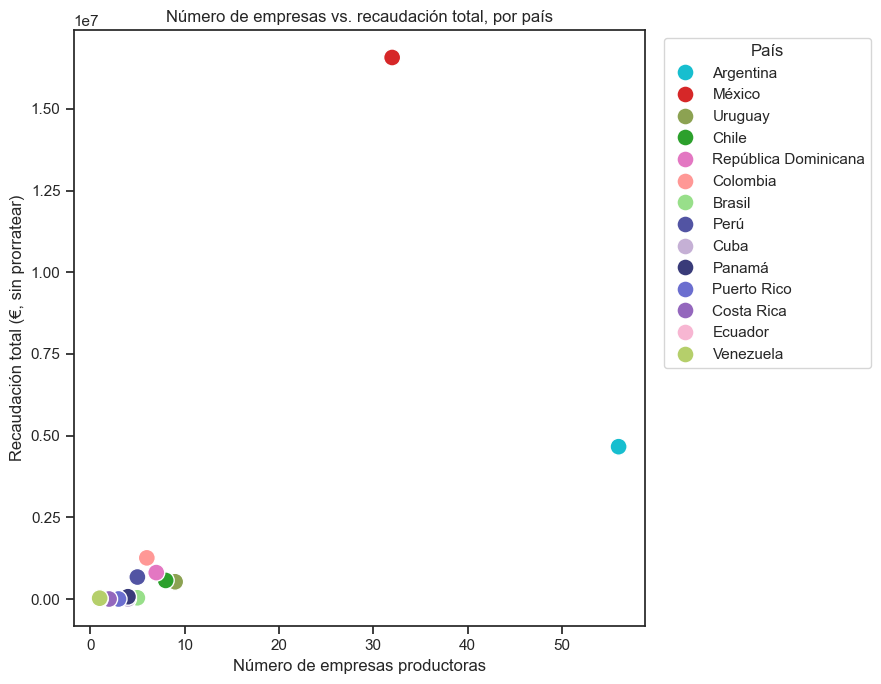

In [125]:
# Reutiliza empresas_por_pais (recién calculada) y una consulta de recaudación
# real por país (sin prorratear, DISTINCT por película para no contar dos veces
# si un país tiene más de una empresa en la misma película).
recaudacion_real_por_pais = consultar("""
    SELECT pa.nombre AS pais, SUM(sub.recaudacion_total) AS recaudacion_total
    FROM (
        SELECT DISTINCT v.pelicula_id, v.recaudacion_total, pep.pais_id
        FROM vista_latam v
        JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    ) AS sub
    JOIN paises pa ON pa.pais_id = sub.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre
""")

num_empresas_vs_recaudacion = empresas_por_pais.merge(recaudacion_real_por_pais, on='pais')

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=num_empresas_vs_recaudacion, x='num_empresas', y='recaudacion_total',
    hue='pais', palette=COLORES_PAISES_NOMBRE, s=150,
)
plt.xlabel('Número de empresas productoras')
plt.ylabel('Recaudación total (€, sin prorratear)')
plt.title('Número de empresas vs. recaudación total, por país')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('num_empresas_vs_recaudacion_pais')
plt.show()


**Lectura:** si México, con menos empresas que Argentina, aparece por
encima en recaudación, es una señal de que su recaudación depende de menos
manos pero de mayor peso individual por empresa -- justo el tipo de
matiz que un índice agregado escondería.

### 11.3 Concentración de mercado por país de origen

% de títulos que concentran las 3 empresas más activas de cada país,
sobre el total de títulos de ese país. **Aviso de lectura**: en países con
muy pocas empresas en total (marcados con `⚠`), el 100% de concentración
es un artefacto del tamaño de muestra, no una señal real de dominio de
mercado -- no es comparable con el 100% de un país que sí tuviera decenas
de empresas.

In [126]:
concentracion_mercado = consultar("""
    SELECT pais,
           SUM(num_peliculas) AS total_titulos_pais,
           MAX(num_peliculas) AS titulos_empresa_principal,
           ROUND(MAX(num_peliculas) / SUM(num_peliculas) * 100, 1) AS pct_concentracion
    FROM (
        SELECT pa.nombre AS pais, pep.empresa_id,
               COUNT(DISTINCT pep.pelicula_id) AS num_peliculas
        FROM vista_latam v
        JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
        JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
        GROUP BY pa.nombre, pep.empresa_id
    ) AS empresa_pais_conteo
    GROUP BY pais
    ORDER BY pct_concentracion DESC
""")
concentracion_mercado

,pais,total_titulos_pais,titulos_empresa_principal,pct_concentracion
0,Ecuador,1.00,1,100.00
1,Venezuela,1.00,1,100.00
2,Perú,9.00,5,55.60
3,Costa Rica,2.00,1,50.00
4,Puerto Rico,3.00,1,33.30
5,Uruguay,12.00,4,33.30
6,Cuba,4.00,1,25.00
7,Panamá,4.00,1,25.00
8,Brasil,5.00,1,20.00
9,México,40.00,7,17.50


C:\Users\teaac\AppData\Local\Temp\ipykernel_15456\3032869271.py:35: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()


Guardado: ..\4 - graficos\concentracion_mercado_pais_empresas_top3.png


C:\Users\teaac\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


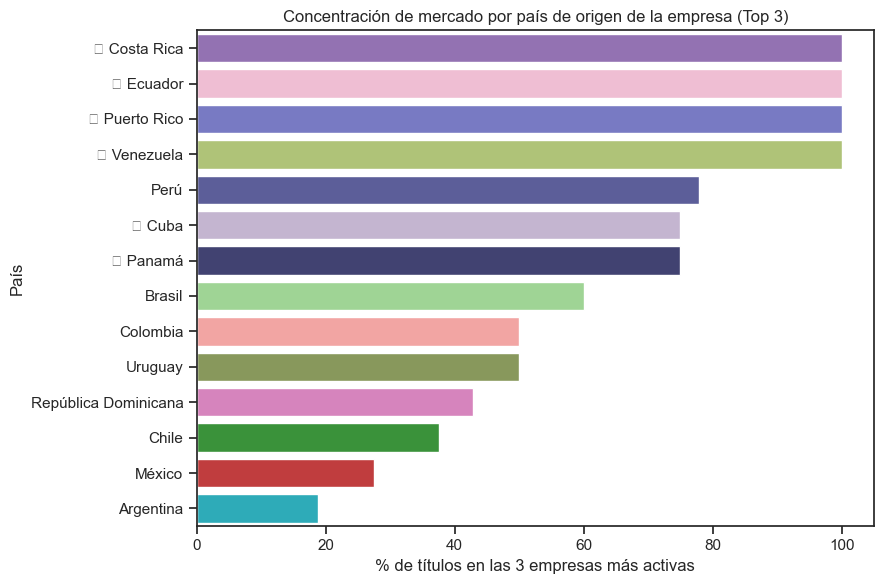

In [127]:
concentracion_pais_empresas = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais, COUNT(DISTINCT v.pelicula_id) AS num_peliculas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.nombre, pa.nombre
""")

filas_concentracion = []
for pais, sub in concentracion_pais_empresas.groupby('pais'):
    total_titulos = sub['num_peliculas'].sum()
    top3 = sub.nlargest(3, 'num_peliculas')['num_peliculas'].sum()
    filas_concentracion.append({
        'pais': pais,
        'num_empresas': len(sub),
        'total_titulos': total_titulos,
        'pct_top3': round(top3 / total_titulos * 100, 1),
    })

concentracion_df = pd.DataFrame(filas_concentracion).sort_values('pct_top3', ascending=False)
concentracion_df['muestra_pequena'] = concentracion_df['num_empresas'] < 5
concentracion_df['pais_etiqueta'] = concentracion_df.apply(
    lambda f: f"⚠ {f['pais']}" if f['muestra_pequena'] else f['pais'], axis=1
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=concentracion_df, y='pais_etiqueta', x='pct_top3',
    hue='pais', palette=COLORES_PAISES_NOMBRE, legend=False,
)
plt.xlabel('% de títulos en las 3 empresas más activas')
plt.ylabel('País')
plt.title('Concentración de mercado por país de origen de la empresa (Top 3)')
plt.tight_layout()
guardar_grafico('concentracion_mercado_pais_empresas_top3')
plt.show()


**Lectura:** ignorando los países marcados con `⚠` (muestra demasiado
pequeña para que el porcentaje diga algo real), Argentina y México --
los dos países con más volumen -- son también los más **fragmentados**
(menor concentración): tienen muchas empresas distintas participando, no
un puñado de grandes productoras dominando. Perú, en cambio, con un
volumen ya razonable (9 títulos, 6 empresas), muestra una concentración
notablemente más alta.

### Concentración por país: total de títulos vs. títulos de la empresa principal

Mismo tipo de gráfico que la concentración de distribuidoras -- aquí cada
punto es un país, el eje X es su volumen total de títulos, el eje Y es
cuántos de esos títulos corresponden a su empresa productora más activa,
y el tamaño de la burbuja es el número de empresas distintas del país. Los
puntos sobre la diagonal son países donde una sola empresa concentra
todo el volumen -- de nuevo, en países con pocas empresas eso es esperable
por tamaño de muestra, no necesariamente una señal de dominio real.

Guardado: ..\4 - graficos\concentracion_pais_empresa_principal_scatter.png


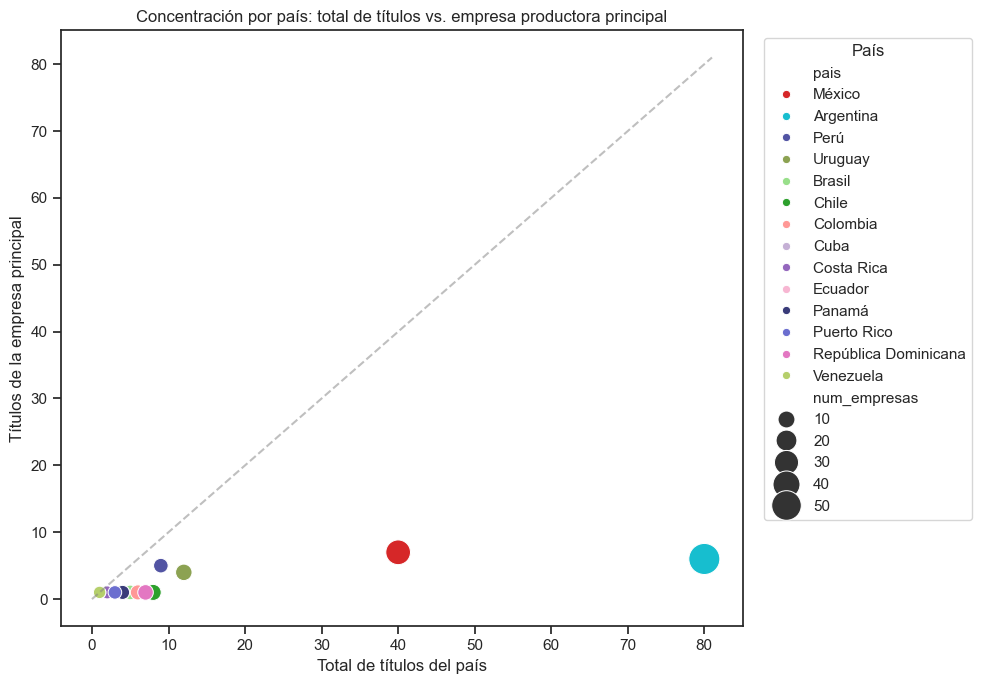

In [128]:
concentracion_pais_scatter = consultar("""
    SELECT pa.nombre AS pais, ep.nombre AS empresa, COUNT(DISTINCT v.pelicula_id) AS num_titulos
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY pa.nombre, ep.nombre
""")

total_por_pais = concentracion_pais_scatter.groupby('pais')['num_titulos'].sum().rename('total_titulos')
num_empresas_por_pais = concentracion_pais_scatter.groupby('pais')['empresa'].nunique().rename('num_empresas')

empresa_principal_por_pais = (
    concentracion_pais_scatter.sort_values('num_titulos', ascending=False)
    .drop_duplicates('pais')
    .rename(columns={'num_titulos': 'titulos_empresa_principal'})
    .merge(total_por_pais, on='pais')
    .merge(num_empresas_por_pais, on='pais')
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=empresa_principal_por_pais, x='total_titulos', y='titulos_empresa_principal',
    hue='pais', palette=COLORES_PAISES_NOMBRE, size='num_empresas', sizes=(80, 500),
)
lim = empresa_principal_por_pais['total_titulos'].max() + 1
plt.plot([0, lim], [0, lim], linestyle='--', color='gray', alpha=0.5)



plt.xlabel('Total de títulos del país')
plt.ylabel('Títulos de la empresa principal')
plt.title('Concentración por país: total de títulos vs. empresa productora principal')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('concentracion_pais_empresa_principal_scatter')
plt.show()


**Lectura:** Argentina y México se alejan claramente de la diagonal --
su empresa más activa (Aleph Media con 6, Sdb con 7) representa una
fracción pequeña de su volumen total, confirmando la fragmentación que ya
vimos en la barra de %top3. El resto de países caen prácticamente sobre
la diagonal, pero con burbujas pequeñas (pocas empresas en total) -- ahí
"una empresa = 100% del país" no es una historia de dominio de mercado,
es simplemente que casi no hay otra opción con la que compararla.

### Cada empresa productora: número de títulos vs. recaudación total

Cada punto es una empresa (144 en total, países LATAM), coloreada por país
de origen -- número de títulos en el eje X, recaudación total (sin
prorratear, sirve como indicador de éxito de la película, no de cuánto
retorno específico tuvo la empresa) en el eje Y. Sin prorrateo porque
`porcentaje_empresa` tiene huecos irregulares entre empresas -- algunas,
como Aleph Media, no tienen el dato en ninguna de sus películas, y
prorratear las habría dejado en cero de forma artificial.

Guardado: ..\4 - graficos\empresas_num_titulos_vs_recaudacion.png


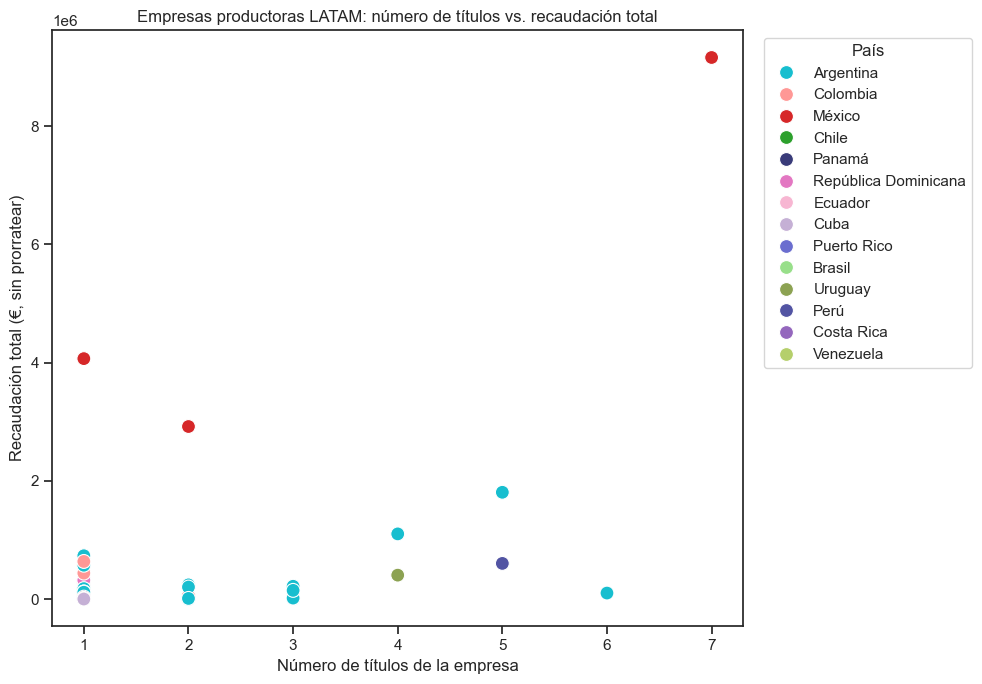

In [129]:
empresas_scatter = consultar("""
    SELECT ep.nombre AS empresa, pa.nombre AS pais,
           COUNT(DISTINCT v.pelicula_id) AS num_titulos,
           SUM(v.recaudacion_total) AS recaudacion_total
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN empresas_productoras ep ON ep.empresa_id = pep.empresa_id
    JOIN paises pa ON pa.pais_id = pep.pais_id AND pa.es_latam = TRUE
    GROUP BY ep.nombre, pa.nombre
""")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=empresas_scatter, x='num_titulos', y='recaudacion_total',
    hue='pais', palette=COLORES_PAISES_NOMBRE, s=100,
)
plt.xlabel('Número de títulos de la empresa')
plt.ylabel('Recaudación total (€, sin prorratear)')
plt.title('Empresas productoras LATAM: número de títulos vs. recaudación total')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
guardar_grafico('empresas_num_titulos_vs_recaudacion')
plt.show()


**Lectura:** la mayoría de las empresas se agrupan cerca del origen (1
título, recaudación modesta) -- coherente con el 11,8% de recurrencia que
ya vimos. Los puntos que se alejan hacia arriba y a la derecha son casos
como Sdb (México, 7 títulos, ~9,2M€) -- volumen y éxito comercial
sostenido, no un pico aislado.

In [130]:
sin_coproduccion_espana = consultar("""
    SELECT v.pelicula_id, v.titulo, v.anio,
           v.recaudacion_total, v.espectadores_total,
           GROUP_CONCAT(DISTINCT pa.nombre ORDER BY pa.nombre SEPARATOR ', ') AS paises_participantes
    FROM vista_latam v
    JOIN participacion_pais pp ON pp.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pp.pais_id
    WHERE v.pelicula_id NOT IN (
        SELECT pp2.pelicula_id
        FROM participacion_pais pp2
        JOIN paises pa2 ON pa2.pais_id = pp2.pais_id
        WHERE pa2.nombre = 'España'
    )
    GROUP BY v.pelicula_id, v.titulo, v.anio, v.recaudacion_total, v.espectadores_total
    ORDER BY v.anio DESC, v.recaudacion_total DESC
""")

print(f"Películas LATAM sin coproducción española: {len(sin_coproduccion_espana)}")
print(f"({len(sin_coproduccion_espana) / consultar('SELECT COUNT(*) AS n FROM vista_latam').iloc[0]['n'] * 100:.1f}% del subset LATAM)")

sin_coproduccion_espana

Películas LATAM sin coproducción española: 8
(5.6% del subset LATAM)


,pelicula_id,titulo,anio,recaudacion_total,espectadores_total,paises_participantes
0,1571,"Jockey, El",2025,"68,525.00",14112,Argentina
1,1003,Llueve sobre Babel,2025,460.00,120,Colombia
2,1056,Emiliana Gat-alana,2025,294.00,37,México
3,1354,"Vuelo de la cigueña, El",2025,28.00,21,México
4,784,"Joven Paulo Coelho, El",2023,524.00,89,Brasil
5,1331,"Hija de todas las rabias, La",2023,359.00,70,Nicaragua
6,1696,"Ombligo de Guie'dani, El",2021,"5,939.00",1080,México
7,685,Sin señas particulares,2021,971.00,277,México


In [131]:
verificacion_cruzada = consultar("""
    SELECT v.pelicula_id, v.titulo,
           GROUP_CONCAT(DISTINCT pa.nombre ORDER BY pa.nombre SEPARATOR ', ') AS paises_via_empresas
    FROM vista_latam v
    JOIN peliculas_empresas_productoras pep ON pep.pelicula_id = v.pelicula_id
    JOIN paises pa ON pa.pais_id = pep.pais_id
    WHERE v.pelicula_id IN (
        SELECT v2.pelicula_id
        FROM vista_latam v2
        WHERE v2.pelicula_id NOT IN (
            SELECT pp2.pelicula_id
            FROM participacion_pais pp2
            JOIN paises pa2 ON pa2.pais_id = pp2.pais_id
            WHERE pa2.nombre = 'España'
        )
    )
    GROUP BY v.pelicula_id, v.titulo
""")
verificacion_cruzada

,pelicula_id,titulo,paises_via_empresas
0,685,Sin señas particulares,España
1,1056,Emiliana Gat-alana,España
2,1571,"Jockey, El",España


In [132]:
pct_latam_por_anio = consultar("""
    SELECT p.anio,
           COUNT(*) AS total_peliculas,
           COUNT(CASE WHEN v.pelicula_id IS NOT NULL THEN 1 END) AS num_latam,
           ROUND(COUNT(CASE WHEN v.pelicula_id IS NOT NULL THEN 1 END) / COUNT(*) * 100, 1) AS pct_latam
    FROM peliculas p
    LEFT JOIN vista_latam v ON v.pelicula_id = p.pelicula_id
    WHERE p.anio BETWEEN 2021 AND 2025
    GROUP BY p.anio
    ORDER BY p.anio
""")
pct_latam_por_anio

,anio,total_peliculas,num_latam,pct_latam
0,2021,461,28,6.10
1,2022,357,24,6.70
2,2023,391,26,6.60
3,2024,358,23,6.40
4,2025,485,43,8.90


Guardado: ..\4 - graficos\evolucion_pct_latam_anual.png


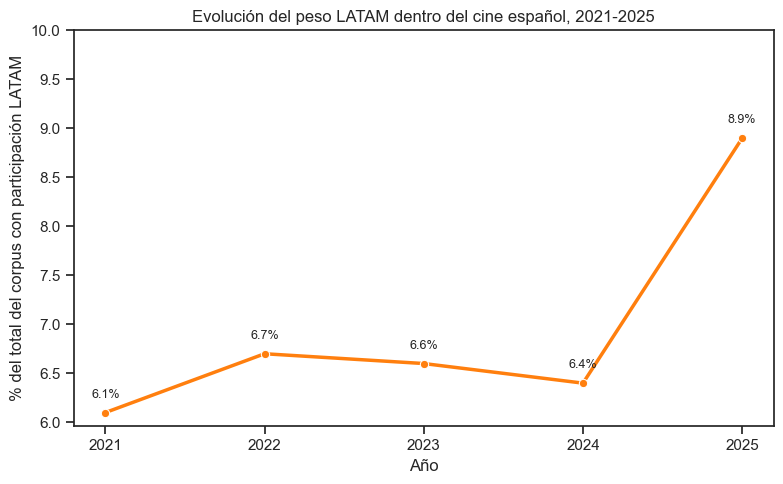

Guardado: ..\4 - graficos\yoy_pct_latam.png


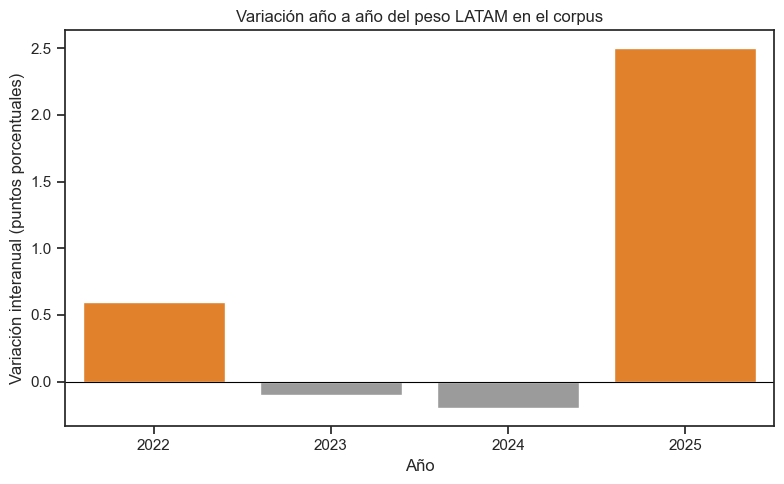

In [133]:
pct_latam_por_anio['yoy_pp'] = pct_latam_por_anio['pct_latam'].diff().round(2)  # cambio en puntos porcentuales
pct_latam_por_anio['yoy_pct_change'] = pct_latam_por_anio['pct_latam'].pct_change().mul(100).round(1)  # cambio relativo %

# Gráfico 1: evolución del % LATAM sobre el total, 2021-2025
plt.figure(figsize=(8, 5))
sns.lineplot(data=pct_latam_por_anio, x='anio', y='pct_latam',
             marker='o', linewidth=2.5, color=COLORES_LATAM['Latinoamérica'])
plt.xticks(pct_latam_por_anio['anio'])
plt.ylim(top=10)
plt.ylabel('% del total del corpus con participación LATAM')
plt.xlabel('Año')
plt.title('Evolución del peso LATAM dentro del cine español, 2021-2025')
for _, fila in pct_latam_por_anio.iterrows():
    plt.text(fila['anio'], fila['pct_latam'] + 0.15, f"{fila['pct_latam']}%", ha='center', fontsize=9)
plt.tight_layout()
guardar_grafico('evolucion_pct_latam_anual')
plt.show()

# Gráfico 2: variación interanual (puntos porcentuales)
plt.figure(figsize=(8, 5))
colores_barras = ['#9B9B9B' if v is None or v <= 0 else COLORES_LATAM['Latinoamérica']
                   for v in pct_latam_por_anio['yoy_pp']]
sns.barplot(data=pct_latam_por_anio.dropna(subset=['yoy_pp']),
            x='anio', y='yoy_pp', hue='anio', palette=colores_barras[1:], legend=False)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Variación interanual (puntos porcentuales)')
plt.xlabel('Año')
plt.title('Variación año a año del peso LATAM en el corpus')
plt.tight_layout()
guardar_grafico('yoy_pct_latam')
plt.show()

---
## Cierre de la conexión

Solo cuando ya termines de explorar en esta sesión -- si sigues corriendo
celdas después, `consultar()` volvería a abrir conexión sola sin fallar,
pero no hay motivo para cerrarla antes de tiempo.

In [134]:
engine.dispose()
print("✓ Conexión cerrada")


✓ Conexión cerrada
